### Files Setup

In [1]:
from google.colab import drive
from pathlib import Path
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
try:
    path = Path('/content/drive/MyDrive/Universidade/Mestrado/2 Semestre/Aprendizagem Computacional Avançada/AML_Butterfly/aca-butterflies')

    if not path.exists():
        raise FileNotFoundError(f"The specified path does not exist: {path}")

except FileNotFoundError:
    path = Path('/content/drive/MyDrive/AdvancedMachineLearning2/aca-butterflies')

if not path.exists():
    raise FileNotFoundError(f"The specified path does not exist: {path}")

print(f"Using path: {path}")

Using path: /content/drive/MyDrive/AdvancedMachineLearning2/aca-butterflies


### Load data

In [3]:
# Load the dataset on Colab machine
!cp "/content/drive/MyDrive/Universidade/Mestrado/2 Semestre/Aprendizagem Computacional Avançada/AML_Butterfly/aca-butterflies.zip" "/content/butterflies.zip"

cp: cannot stat '/content/drive/MyDrive/Universidade/Mestrado/2 Semestre/Aprendizagem Computacional Avançada/AML_Butterfly/aca-butterflies.zip': No such file or directory


In [4]:
!cp "/content/drive/MyDrive/AdvancedMachineLearning2/aca-butterflies.zip" "/content/butterflies.zip"

In [5]:
# Il flag -o forza la sovrascrittura automatica senza fare domande!
!unzip -o -q /content/butterflies.zip -d /content/dataset_local

In [6]:
import os
from PIL import Image
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.utils.data as data
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms

# ============================================================
# GENERATIVE METRICS: FID, Inception Score, SSIM
# ============================================================
# Installazione (esegui una volta su Colab)
!pip install torchmetrics[image] -q

from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore
from torchmetrics.image import StructuralSimilarityIndexMeasure

import warnings
warnings.filterwarnings("ignore")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 67.6 MB/s eta 0:00:00


In [7]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


In [8]:
BATCH_SIZE = 32
IMAGE_SIZE = 64

In [9]:
class ButterflyDataset(data.Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.img_labels = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

        self.classes = sorted(self.img_labels['label'].unique())
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_name = self.img_labels.iloc[idx]['filename']
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        label_name = self.img_labels.iloc[idx]['label']
        label_idx = self.class_to_idx[label_name]
        label = torch.tensor(label_idx, dtype=torch.long)

        if self.transform:
            image = self.transform(image)

        return image, label

## First, we read the dataset, preprocess the images and encapsulate them into dataloader form.

In [10]:
# load the data
img_dir = Path("/content/dataset_local/train")
test_dir = Path("/content/dataset_local/test")
# img_dir = os.path.join(path, 'train')
df = pd.read_csv(os.path.join(path, 'train.csv'))

# preprocessing
# immagini comprese tra 0 e 1, ridimensionate a 64x64
data_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

# encapsulate data into dataloader form
dataset = ButterflyDataset(df=df, img_dir=img_dir, transform=data_transform)
print(f"Dataset size: {len(dataset)} samples")
dataloader = data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

Dataset size: 5199 samples


In [11]:
print(f"Number of samples: {len(dataset)}")
print(f"Number of classes: {len(dataset.classes)}")

Number of samples: 5199
Number of classes: 75


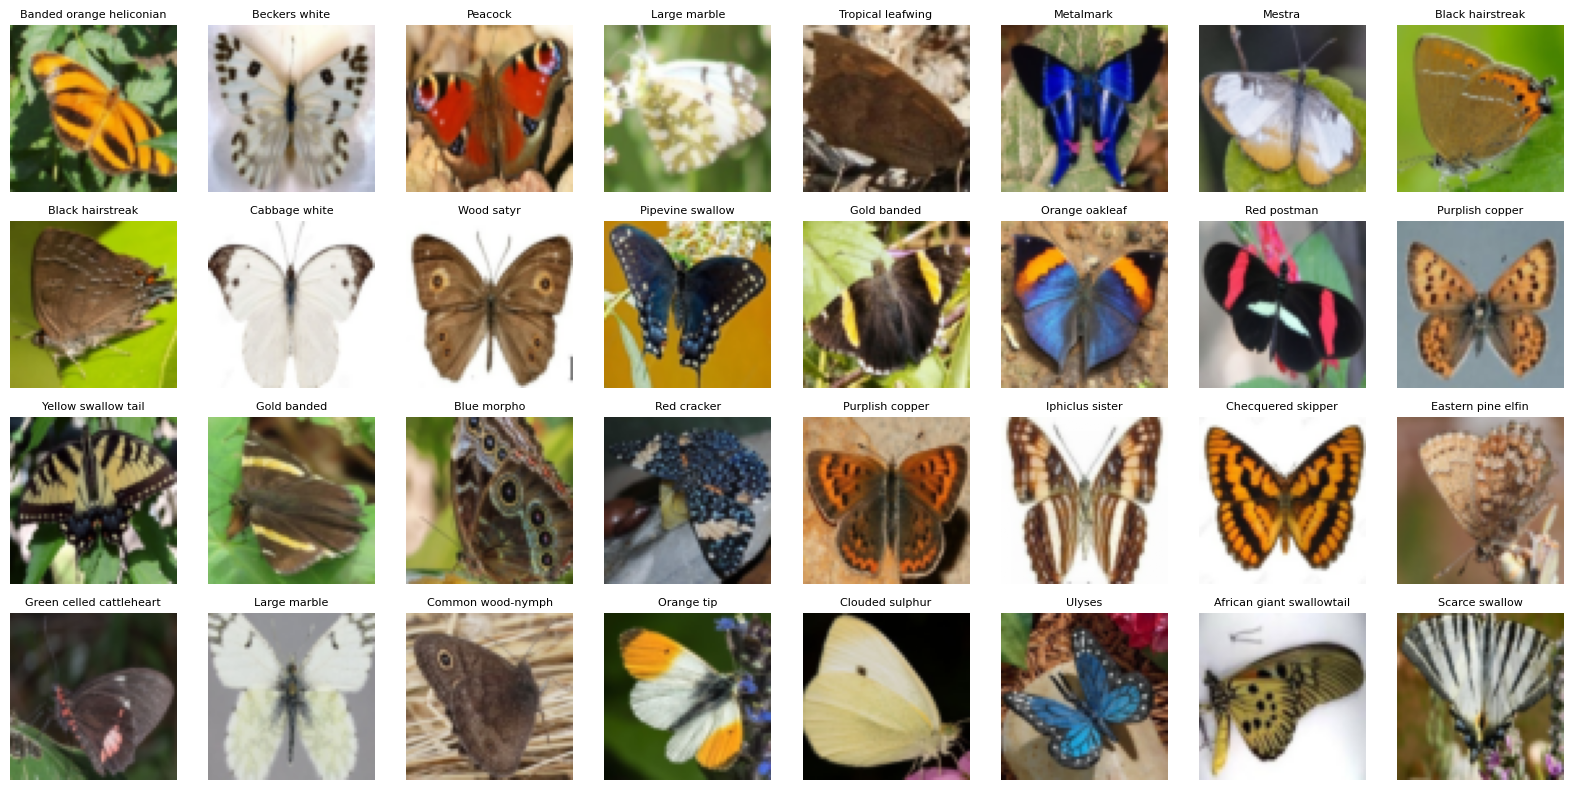

In [12]:
# Get a batch of images from the dataloader
images, labels = next(iter(dataloader))

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()

for i, img in enumerate(images):
    img = img.permute(1, 2, 0).numpy()
    label_idx = labels[i].item()
    label_name = dataset.classes[label_idx]
    axes[i].imshow(img)
    axes[i].set_title(label_name.capitalize(), fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Preparation
In this section we divide the dataset into train, validation and test.

In [13]:
from sklearn.model_selection import train_test_split

# 1.First we split the data into training/validation (85%) and test (15%)
train_val_df, test_df = train_test_split(
    df,
    test_size=0.15,
    random_state=42,
    stratify=df['label']
)

# 2. Then, we split the remaining data between training and validation
# 0.176 aprox represents 15% of the original total (0.15 / 0.85)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.176,
    random_state=42,
    stratify=train_val_df['label']
)

print(f"Training: {len(train_df)} | Validation: {len(val_df)} | Test: {len(test_df)}")

#* DataLoaders
# Training
train_dataset = ButterflyDataset(df=train_df, img_dir=img_dir, transform=data_transform)
train_loader = data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Validation
val_dataset = ButterflyDataset(df=val_df, img_dir=img_dir, transform=data_transform)
val_loader = data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Test
test_dataset = ButterflyDataset(df=test_df, img_dir=img_dir, transform=data_transform)
test_loader = data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


Training: 3641 | Validation: 778 | Test: 780


In [14]:
import pandas as pd
import torch
from PIL import Image
import os

def  generate_kaggle_submission(model, test_dir, transform, device, class_names, save_name='submission.csv'):
    """
    Args:
        model: Trained model.
        test_dir: Path to the test folder.
        transform: Transformations for validation/test.
        device: 'cuda' or 'cpu'.
        class_names: List with the names of the classes (e.g., train_dataset.classes).
        save_name: Name of the CSV file.
    """
    model.eval()
    results = []
    
    # List all image files in the test directory (assuming they are .jpg, .png, or .jpeg)
    test_files = sorted([f for f in os.listdir(test_dir) if f.endswith(('.jpg', '.png', '.jpeg'))])
    
    print(f"Processing {len(test_files)} images for the submission...")
    
    with torch.no_grad():
        for filename in test_files:
            # 1. Upload the image and apply the same transformations as validation/test
            img_path = os.path.join(test_dir, filename)
            image = Image.open(img_path).convert('RGB')
            input_tensor = transform(image).unsqueeze(0).to(device)
            
            # 2. Predict the class index
            outputs = model(input_tensor)
            _, predicted_idx = torch.max(outputs, 1)
            
            # 3. Convert the predicted index to the class name
            # predicted_idx.item() gives the number, class_names[...] gives the name
            label_extenso = class_names[predicted_idx.item()]
            
            results.append({
                "filename": filename,
                "label": label_extenso
            })
            
    # 4. Create the CSV
    df = pd.DataFrame(results)
    save_dir = os.path.dirname(path)
    df.to_csv(os.path.join(save_dir, save_name), index=False)
    print(f"Success! Submission saved to: {os.path.join(save_dir, save_name)}")
    return df

### Generative Metrics
We make the code for the 3 metrics to compute for check if the generations goes well:
1) FID
2) Inception Distance
3) SSIM
   

In [15]:
def compute_fid(real_images_tensor, fake_images_tensor, device, batch_size=32):
    """
    Calcola il Fréchet Inception Distance (FID) tra immagini reali e generate.
    Valori più bassi = immagini generate più simili alla distribuzione reale.
    
    Args:
        real_images_tensor: Tensor (N, 3, H, W) in [0, 1]
        fake_images_tensor: Tensor (N, 3, H, W) in [0, 1]
    Returns:
        fid_score (float)
    """
    
    # 2048 is the standard feature dimension used for FID with InceptionV3.
    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)

    # Aggiorna con batch di immagini reali
    # we have batches of 32, so we loop through the tensors in steps of batch_size
    # for avoid OOM error when processing all images at once
    for i in range(0, len(real_images_tensor), batch_size):
        batch = real_images_tensor[i:i+batch_size].to(device)
        fid.update(batch, real=True)

    # Update with batches of generated images
    for i in range(0, len(fake_images_tensor), batch_size):
        batch = fake_images_tensor[i:i+batch_size].to(device)
        fid.update(batch, real=False)

    score = fid.compute().item()
    print(f"FID Score: {score:.4f}  (↓ meglio)")
    return score


def compute_inception_score(fake_images_tensor, device, batch_size=32, splits=10):
    """
    Calcola l'Inception Score (IS) sulle immagini generate.
    Valori più alti = immagini più realistiche e diverse tra loro.
    
    Args:
        fake_images_tensor: Tensor (N, 3, H, W) in [0, 1]
    Returns:
        (is_mean, is_std)
    """
    inception = InceptionScore(normalize=True, splits=splits).to(device)

    for i in range(0, len(fake_images_tensor), batch_size):
        batch = fake_images_tensor[i:i+batch_size].to(device)
        inception.update(batch)

    is_mean, is_std = inception.compute()
    print(f"Inception Score: {is_mean.item():.4f} ± {is_std.item():.4f}  (↑ meglio)")
    return is_mean.item(), is_std.item()


def compute_ssim(real_images_tensor, fake_images_tensor, device, batch_size=32):
    """
    Calcola lo Structural Similarity Index (SSIM) tra coppie di immagini.
    1.0 = identiche, 0.0 = completamente diverse.
    Utile per valutare la qualità delle ricostruzioni del VAE.
    
    Args:
        real_images_tensor: Tensor (N, 3, H, W) in [0, 1]
        fake_images_tensor: Tensor (N, 3, H, W) in [0, 1]  (stessa lunghezza)
    Returns:
        ssim_score (float)
    """
    ssim = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

    scores = []
    for i in range(0, len(real_images_tensor), batch_size):
        real_batch = real_images_tensor[i:i+batch_size].to(device)
        fake_batch = fake_images_tensor[i:i+batch_size].to(device)
        score = ssim(fake_batch, real_batch)
        scores.append(score.item())

    ssim_score = np.mean(scores)
    print(f"SSIM Score: {ssim_score:.4f}  (↑ meglio, max 1.0)")
    return ssim_score

In [16]:
def evaluate_all_generative_metrics(model, model_name, real_loader, device, n_samples=2000, latent_dim=None, n_classes=None, model_type='gan'):
    """
    Funzione unica che raccoglie immagini reali e generate,
    poi calcola FID, IS e SSIM in un colpo solo.
    
    Args:
        model_type: 'gan' per GAN/cGAN, 'vae' per VAE/cVAE
    """
    print(f"\n{'='*50}")
    print(f"Metriche generative: {model_name}")
    print(f"{'='*50}")

    model.eval()

    # --- Raccolta immagini reali ---
    real_images = []
    with torch.no_grad():
        for imgs, _ in real_loader:
            real_images.append(imgs)
            if sum(x.shape[0] for x in real_images) >= n_samples:
                break
    real_images = torch.cat(real_images)[:n_samples]  # (N, 3, H, W) in [0,1]

    # --- Generazione immagini sintetiche ---
    fake_images = []
    labels_for_gen = torch.randint(0, n_classes, (n_samples,))

    with torch.no_grad():
        for i in range(0, n_samples, 64):
            batch_labels = labels_for_gen[i:i+64].to(device)
            bs = len(batch_labels)

            if model_type == 'gan':
                noise = torch.randn(bs, latent_dim, device=device)
                imgs = model(noise, batch_labels)
                imgs = (imgs + 1) / 2  # [-1,1] → [0,1]

            elif model_type == 'vae':
                # Campiona dallo spazio latente
                z = torch.randn(bs, model.latent_dim, device=device)
                imgs = model.decode(z, batch_labels)
                imgs = imgs.clamp(0, 1)

            fake_images.append(imgs.cpu())

    fake_images = torch.cat(fake_images)[:n_samples]

    # --- Calcolo metriche ---
    fid   = compute_fid(real_images, fake_images, device)
    is_m, is_s = compute_inception_score(fake_images, device)
    ssim  = compute_ssim(real_images, fake_images, device)

    results = {
        'model': model_name,
        'FID':   round(fid, 4),
        'IS_mean': round(is_m, 4),
        'IS_std':  round(is_s, 4),
        'SSIM':  round(ssim, 4)
    }

    return results

### Trasformation for Preprocessing of data

In [17]:
# ============================================================
# TRANSFORMS SEPARATION
# ============================================================
# In this project we use DIFFERENT transforms depending on the task:
#
# 1) CLASSIFIER CNN
#    -> needs stronger augmentations to improve generalization
#    -> uses Normalize() for stable training
#
# 2) GENERATIVE MODELS (VAE / GAN / cGAN)
#    -> must see REAL images without aggressive augmentations
#    -> VAE outputs images in [0,1] because of Sigmoid()
#    -> therefore NO Normalize([-1,1]) for the VAE
#
# This separation is VERY important.
# ============================================================

# ============================================================
# 1. TRANSFORMS FOR CLASSIFIER CNN
# ============================================================
# Used for:
# - Baseline CNN
# - Augmented CNN
#
# Goal:
# Improve robustness and reduce overfitting.
# ============================================================

# questa serve per la simple augmentation della baselineCNN
train_transform_augmentation = transforms.Compose([

    # Resize all images to a fixed size
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    # Data augmentation
    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(degrees=15),

    # Data augmentation cromatica (Color Jitter)
    # Parametri: brightness (luminosità), contrast (contrasto), saturation (saturazione), hue (tonalità)
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),

    # Convert PIL image -> Tensor
    transforms.ToTensor()
])


# ============================================================
# VALIDATION / TEST TRANSFORMS FOR CLASSIFIER
# ============================================================
# IMPORTANT:
# No augmentations on validation and test sets.
# We only normalize.
# ============================================================

val_test_transform_augmentation = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor()
])


# ============================================================
# 2. TRANSFORMS FOR GENERATIVE MODELS
# ============================================================
# Used for:
# - VAE
# - cVAE
# - GAN
# - cGAN
#
# IMPORTANT:
# We DO NOT use Normalize([-1,1]) for the VAE because:
#
# - the decoder uses Sigmoid()
# - outputs are in [0,1]
#
# Therefore input images must also stay in [0,1].
#
# We also avoid aggressive augmentations because
# generative models must learn the REAL data distribution.
# ============================================================

gen_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor()

])


# ============================================================
# DATASETS FOR CLASSIFIER
# ============================================================

train_dataset_augmentation = ButterflyDataset(
    df=train_df,
    img_dir=img_dir,
    transform=train_transform_augmentation
)

val_dataset_augmentation = ButterflyDataset(
    df=val_df,
    img_dir=img_dir,
    transform=val_test_transform_augmentation
)

test_dataset_augmentation = ButterflyDataset(
    df=test_df,
    img_dir=img_dir,
    transform=val_test_transform_augmentation
)


# ============================================================
# DATALOADERS FOR CLASSIFIER
# ============================================================

train_loader_augmentation = data.DataLoader(
    train_dataset_augmentation,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader_augmentation = data.DataLoader(
    val_dataset_augmentation,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader_augmentation = data.DataLoader(
    test_dataset_augmentation,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ============================================================
# DATASET FOR GENERATIVE MODELS
# ============================================================

gen_dataset = ButterflyDataset(
    df=train_df,
    img_dir=img_dir,
    transform=gen_transform
)


# ============================================================
# DATALOADER FOR GENERATIVE MODELS
# ============================================================

gen_loader = data.DataLoader(
    gen_dataset,
    batch_size=64,
    shuffle=True
)


# ============================================================
# FINAL SUMMARY
# ============================================================
#
# CLASSIFIER:
#   train_loader_augmentation
#   val_loader_augmentation
#   test_loader_augmentation
#
# GENERATIVE MODELS:
#   gen_loader
#
# ============================================================

### Save the augmented dataset

In [38]:
import os
import shutil
import pandas as pd
import torchvision.transforms as T
from tqdm import tqdm

DRIVE_FOLDER = "AdvancedMachineLearning2"

def export_dataset_to_zip(dataset_obj, train_df, zip_filename, drive_folder):
    """
    Esporta un qualsiasi Dataset PyTorch in una struttura piatta, genera il file CSV 
    di indice e salva l'archivio ZIP direttamente su Google Drive per la consegna.
    
    Args:
        dataset_obj: Il dataset PyTorch combinato da esportare (es. combined_dataset)
        train_df: Il DataFrame originale da cui estrarre la lista alfabetica delle classi
        zip_filename: Nome del file ZIP finale (senza estensione)
        drive_folder: Nome della cartella di destinazione su Google Drive
    """
    # 1. Configurazione dei percorsi di Google Drive e locali
    drive_base_path = f"/content/drive/MyDrive/{drive_folder}"
    os.makedirs(drive_base_path, exist_ok=True)
    
    final_zip_drive_path = os.path.join(drive_base_path, zip_filename)
    temp_dir = f"/content/temp_{zip_filename}"
    images_output_dir = os.path.join(temp_dir, "train_images")
    
    # 2. Pulizia di vecchi residui e creazione directory temporanea locale
    if os.path.exists(temp_dir):
        shutil.rmtree(temp_dir)
    os.makedirs(images_output_dir, exist_ok=True)
    
    # Estrazione automatica e sicura di class_names in ordine alfabetico
    class_names = sorted(train_df['label'].unique())
    to_pil = T.ToPILImage()
    csv_records = []
    
    print(f"Esportazione piatta di {len(dataset_obj)} immagini per '{zip_filename}'...")
    
    # 3. Iterazione sul dataset e salvataggio delle immagini PNG locali
    for idx in tqdm(range(len(dataset_obj))):
        try:
            img_tensor, label_idx = dataset_obj[idx]
            class_name = class_names[label_idx]
            
            # Nome file piatto univoco
            file_name = f"aug_img_{idx:05d}.png"
            file_path = os.path.join(images_output_dir, file_name)
            
            # Salvataggio fisico dell'immagine
            pil_img = to_pil(img_tensor)
            pil_img.save(file_path)
            
            # Registrazione per il CSV
            csv_records.append({
                "image_name": file_name,
                "label": class_name
            })
        except Exception as e:
            continue
            
    # 4. Generazione del file CSV coordinato dentro la cartella temporanea
    df_csv = pd.DataFrame(csv_records)
    csv_path = os.path.join(temp_dir, "train_augmented.csv")
    df_csv.to_csv(csv_path, index=False)
    
    print(f"\n[INFO] Creato file di indice '{csv_path}' con {len(df_csv)} righe.")
    
    # 5. Compressione e scrittura DIRETTA su Google Drive
    print(f"Compressione e salvataggio su Google Drive in corso...")
    print(f"Destinazione: MyDrive/{drive_folder}/{zip_filename}.zip")
    shutil.make_archive(final_zip_drive_path, 'zip', temp_dir)
    
    # 6. Pulizia della cartella temporanea locale su Colab
    shutil.rmtree(temp_dir)
    print(f"[SUCCESS] Archivio '{zip_filename}.zip' pronto su Google Drive!\n")

### Augmented Tensor Dataset

In [ ]:
from torch.utils.data import Dataset

class AugmentedTensorDataset(Dataset):
    """
    Custom Dataset designed to wrap and manipulate synthetic image tensors 
    generated in-memory by cVAE and cGAN frameworks, supporting on-the-fly 
    geometric augmentations.
    """
    def __init__(self, tensors_img, tensors_lbl, transform=None):
        self.tensors_img = tensors_img
        self.tensors_lbl = tensors_lbl
        self.transform = transform

    def __getitem__(self, index):
        img = self.tensors_img[index]
        lbl = self.tensors_lbl[index]
        
        if self.transform:
            img = self.transform(img)
            
        return img, lbl

    def __len__(self):
        return len(self.tensors_img)

# Classifier

In [18]:
import torch.nn as nn

class BaselineCNN(nn.Module):
    def __init__(self, num_classes):

        """
        Baseline Convolutional Neural Network for Butterfly Classification.
        
        Args:
            num_classes (int): Number of target species/classes (75 for this dataset).
        """

        super().__init__()

        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                # Layer 1: Convolutional feature extraction preserving spatial dimensions
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                
                # Layer 2: Second convolution to build deeper feature representations
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),

                # Downsamples spatial dimensions by 2x (Height and Width halved)
                nn.MaxPool2d(2, 2)
            )

        # Feature Extractor: Progressively extracts high-level semantic abstractions
        self.features = nn.Sequential(
            conv_block(3, 64), # Input: 3 channels (RGB) -> Output: 64 channels
            conv_block(64, 128), # Input: 64 channels      -> Output: 128 channels
            conv_block(128, 256), # Input: 128 channels     -> Output: 256 channels
            # Global pooling forces spatial dimensions to 1x1, minimizing dense layer parameters
            nn.AdaptiveAvgPool2d((1, 1))
        )

        # Fully Connected Classifier: Maps extracted features to final class logits
        self.classifier = nn.Sequential(
            *[layer for size in [256, 512, 1024]
            for layer in (nn.Linear(size, size*2), nn.ReLU(inplace=True), nn.Dropout(p=0.5))],
            # Final output layer: Maps 2048 hidden units to the 75 butterfly classes
            nn.Linear(2048, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

### Training Loop

In [19]:
import copy
import torch

def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=25, patience=5, scheduler=None):
    model = model.to(device)
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    # Early Stopping variables
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_loss = float('inf')
    epochs_no_improve = 0
    
    for epoch in range(num_epochs):
        print(f'[{epoch+1}/{num_epochs}]', end=' ')
        
        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode (enables Dropout, BatchNorm, etc.)
                dataloader = train_loader
            else:
                model.eval()   # Set model to evaluation mode (disables Dropout, etc.)
                dataloader = val_loader
                
            running_loss = 0.0
            running_corrects = 0
            total_samples = 0
            
            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                optimizer.zero_grad()
                
                # Forward pass
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    
                    # Backward e and optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                        
                # Stats
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels).item()
                total_samples += inputs.size(0)
                
            epoch_loss = running_loss / total_samples
            epoch_acc = running_corrects / total_samples
            
            print(f'{phase.capitalize()}: Loss = {epoch_loss:.4f} Accuracy = {epoch_acc*100:.2f}% |', end=' ')
            
            # Save history
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc)
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc)
                
                # Update Scheduler if exists (based on Validation Loss)
                if scheduler is not None:
                    scheduler.step(epoch_loss)
                
                # Early Stopping logic
                if epoch_loss < best_val_loss:
                    best_val_loss = epoch_loss
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1
        
        # Early Stopping check after each epoch
        if epochs_no_improve >= patience:
            print(f'\nEarly stopping at epoch {epoch+1}! Validation loss did not improve for {patience} epochs.')
            break
            
        print()
        
    print(f'\nBest Validation Loss: {best_val_loss:.4f}')
    
    model.load_state_dict(best_model_wts)
    return history

In [20]:
n_classes = len(train_dataset.classes)
print(f"Number of classes: {n_classes}")
model = BaselineCNN(num_classes=n_classes)
# we can insert the weight decay in the optimizer for regularization (L2)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

num_epochs = 30  
patience = 5   

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
        
history = train_model(
    model=model, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    criterion=criterion, 
    optimizer=optimizer, 
    device=device,
    num_epochs=num_epochs,          # Max epochs for training
    patience=patience,              # Early stopping patience (number of epochs with no improvement after which training will be stopped)
    scheduler=scheduler
)

Number of classes: 75
[1/30] Train: Loss = 4.1817 Accuracy = 2.33% | Val: Loss = 4.1878 Accuracy = 2.06% | 
[2/30] Train: Loss = 3.9761 Accuracy = 3.49% | Val: Loss = 3.9074 Accuracy = 3.86% | 
[3/30] Train: Loss = 3.7899 Accuracy = 6.29% | Val: Loss = 3.6163 Accuracy = 7.07% | 
[4/30] Train: Loss = 3.6411 Accuracy = 7.11% | Val: Loss = 3.5579 Accuracy = 9.25% | 
[5/30] Train: Loss = 3.5066 Accuracy = 9.50% | Val: Loss = 3.3899 Accuracy = 10.28% | 
[6/30] Train: Loss = 3.3870 Accuracy = 9.94% | Val: Loss = 3.3785 Accuracy = 10.67% | 
[7/30] Train: Loss = 3.3238 Accuracy = 11.34% | Val: Loss = 3.3272 Accuracy = 12.85% | 
[8/30] Train: Loss = 3.2616 Accuracy = 11.81% | Val: Loss = 3.1414 Accuracy = 13.50% | 
[9/30] Train: Loss = 3.1792 Accuracy = 13.81% | Val: Loss = 3.1135 Accuracy = 15.04% | 
[10/30] Train: Loss = 3.1201 Accuracy = 14.20% | Val: Loss = 2.9787 Accuracy = 17.10% | 
[11/30] Train: Loss = 3.0346 Accuracy = 15.52% | Val: Loss = 2.7510 Accuracy = 21.59% | 
[12/30] Train: Los

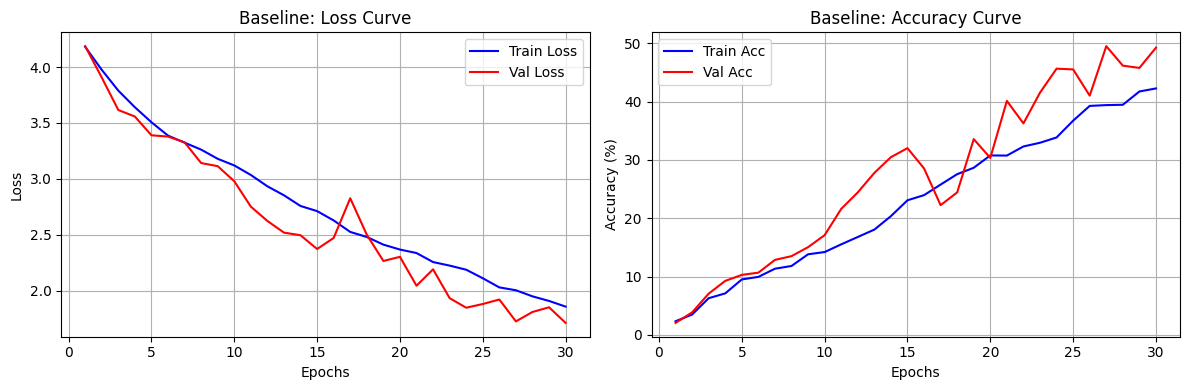

🎯 Il punto di partenza è stabilito! Accuratezza massima della Baseline sulla Validazione: 49.49%


In [21]:
import matplotlib.pyplot as plt

# Estraiamo i dati salvati nella variabile history
epochs_range = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(12, 4))

# Subplot per la Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss', color='blue')
plt.plot(epochs_range, history['val_loss'], label='Val Loss', color='red')
plt.title('Baseline: Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Subplot per l'Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, [acc * 100 for acc in history['train_acc']], label='Train Acc', color='blue')
plt.plot(epochs_range, [acc * 100 for acc in history['val_acc']], label='Val Acc', color='red')
plt.title('Baseline: Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Stampiamo il verdetto finale
best_acc = max(history['val_acc']) * 100
print(f"🎯 Il punto di partenza è stabilito! Accuratezza massima della Baseline sulla Validazione: {best_acc:.2f}%")

### Evaluation on Test

In [22]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tabulate import tabulate

def evaluate_on_test(model, test_loader, device, class_names=None):
    """
    Evaluates the final model on the Test Set and prints the classification report and confusion matrix.
    Args:
        model: the trained model to evaluate
        test_loader: DataLoader for the test set
        device: 'cuda' or 'cpu'
        class_names: list of class names corresponding to the labels (optional, for better report readability)
    """
    model.to(device)
    model.eval()

    test_corrects = 0
    test_total = 0

    all_preds = []
    all_labels = []

    print("Evaluating the final model on the Test Set...")
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            test_corrects += torch.sum(predicted == labels).item()
            test_total += labels.size(0)

            # Save predictions and labels for the report and confusion matrix
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    
    test_accuracy = test_corrects / test_total
    print(f"Test Accuracy: {test_accuracy*100:.2f}%")
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    print(f"Macro F1-score: {macro_f1:.4f}")
    print("\n" + "="*15)
    print("FINAL RESULTS (TEST SET)")
    print("="*15 + "\n")


    report = classification_report(all_labels,all_preds, target_names=class_names, output_dict=True, zero_division=0)

    print(classification_report( all_labels, all_preds, target_names=class_names, zero_division=0))

    # =========================
    # WORST CLASSES
    # =========================

    class_metrics = []

    # Iteriamo su tutte le classi per estrarre F1, Precision, Recall e ID numerico
    for idx, cls_name in enumerate(class_names):
        # Estraiamo le metriche calcolate da sklearn
        f1 = report[cls_name]['f1-score']
        precision = report[cls_name]['precision']
        recall = report[cls_name]['recall']
        support = int(report[cls_name]['support']) # Numero di campioni reali nel test set
        
        class_metrics.append({
            "Class ID": idx,
            "Species Name": cls_name,
            "Precision": precision,
            "Recall": recall,
            "F1-score": f1,
            "Samples": support
        })

    # Ordiniamo le classi in base all'F1-score crescente (le peggiori per prime)
    worst_classes = sorted(class_metrics, key=lambda x: x["F1-score"])[:10]

    # Convertiamo in un DataFrame per una formattazione impeccabile
    df_worst_table = pd.DataFrame(worst_classes)

    print("\n" + "="*95)
    print("      TABLE 1: AUTOMATIC QUANTITATIVE ANALYSIS OF THE 10 ISOLATED WEAK CLASSES      ")
    print("="*95)
    # Stampiamo la tabella finale formattata in stile scientifico pronta da copiare
    print(tabulate(df_worst_table, headers='keys', tablefmt='fancy_grid', showindex=False))
    print("="*95)
    

    # Generate and Plot the Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(20, 16))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)

    plt.title('Confusion Matrix', fontsize=16)
    plt.ylabel('True Class', fontsize=12)
    plt.xlabel('Predicted Class', fontsize=12)


    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    return {
    'accuracy': test_accuracy,
    'macro_f1': macro_f1,
    'labels': all_labels,
    'predictions': all_preds,
    'worst_classes': worst_classes
}

Evaluating the final model on the Test Set...
Test Accuracy: 50.51%
Macro F1-score: 0.4702

FINAL RESULTS (TEST SET)

                           precision    recall  f1-score   support

                   ADONIS       0.69      1.00      0.81        11
AFRICAN GIANT SWALLOWTAIL       0.47      0.89      0.62         9
           AMERICAN SNOOT       0.60      0.33      0.43         9
                    AN 88       1.00      0.40      0.57        10
                  APPOLLO       0.71      0.91      0.80        11
                    ATALA       0.83      0.83      0.83        12
 BANDED ORANGE HELICONIAN       0.67      0.33      0.44        12
           BANDED PEACOCK       1.00      0.50      0.67        10
            BECKERS WHITE       0.25      0.10      0.14        10
         BLACK HAIRSTREAK       0.67      0.80      0.73        10
              BLUE MORPHO       0.36      0.44      0.40         9
        BLUE SPOTTED CROW       0.30      0.30      0.30        10
          

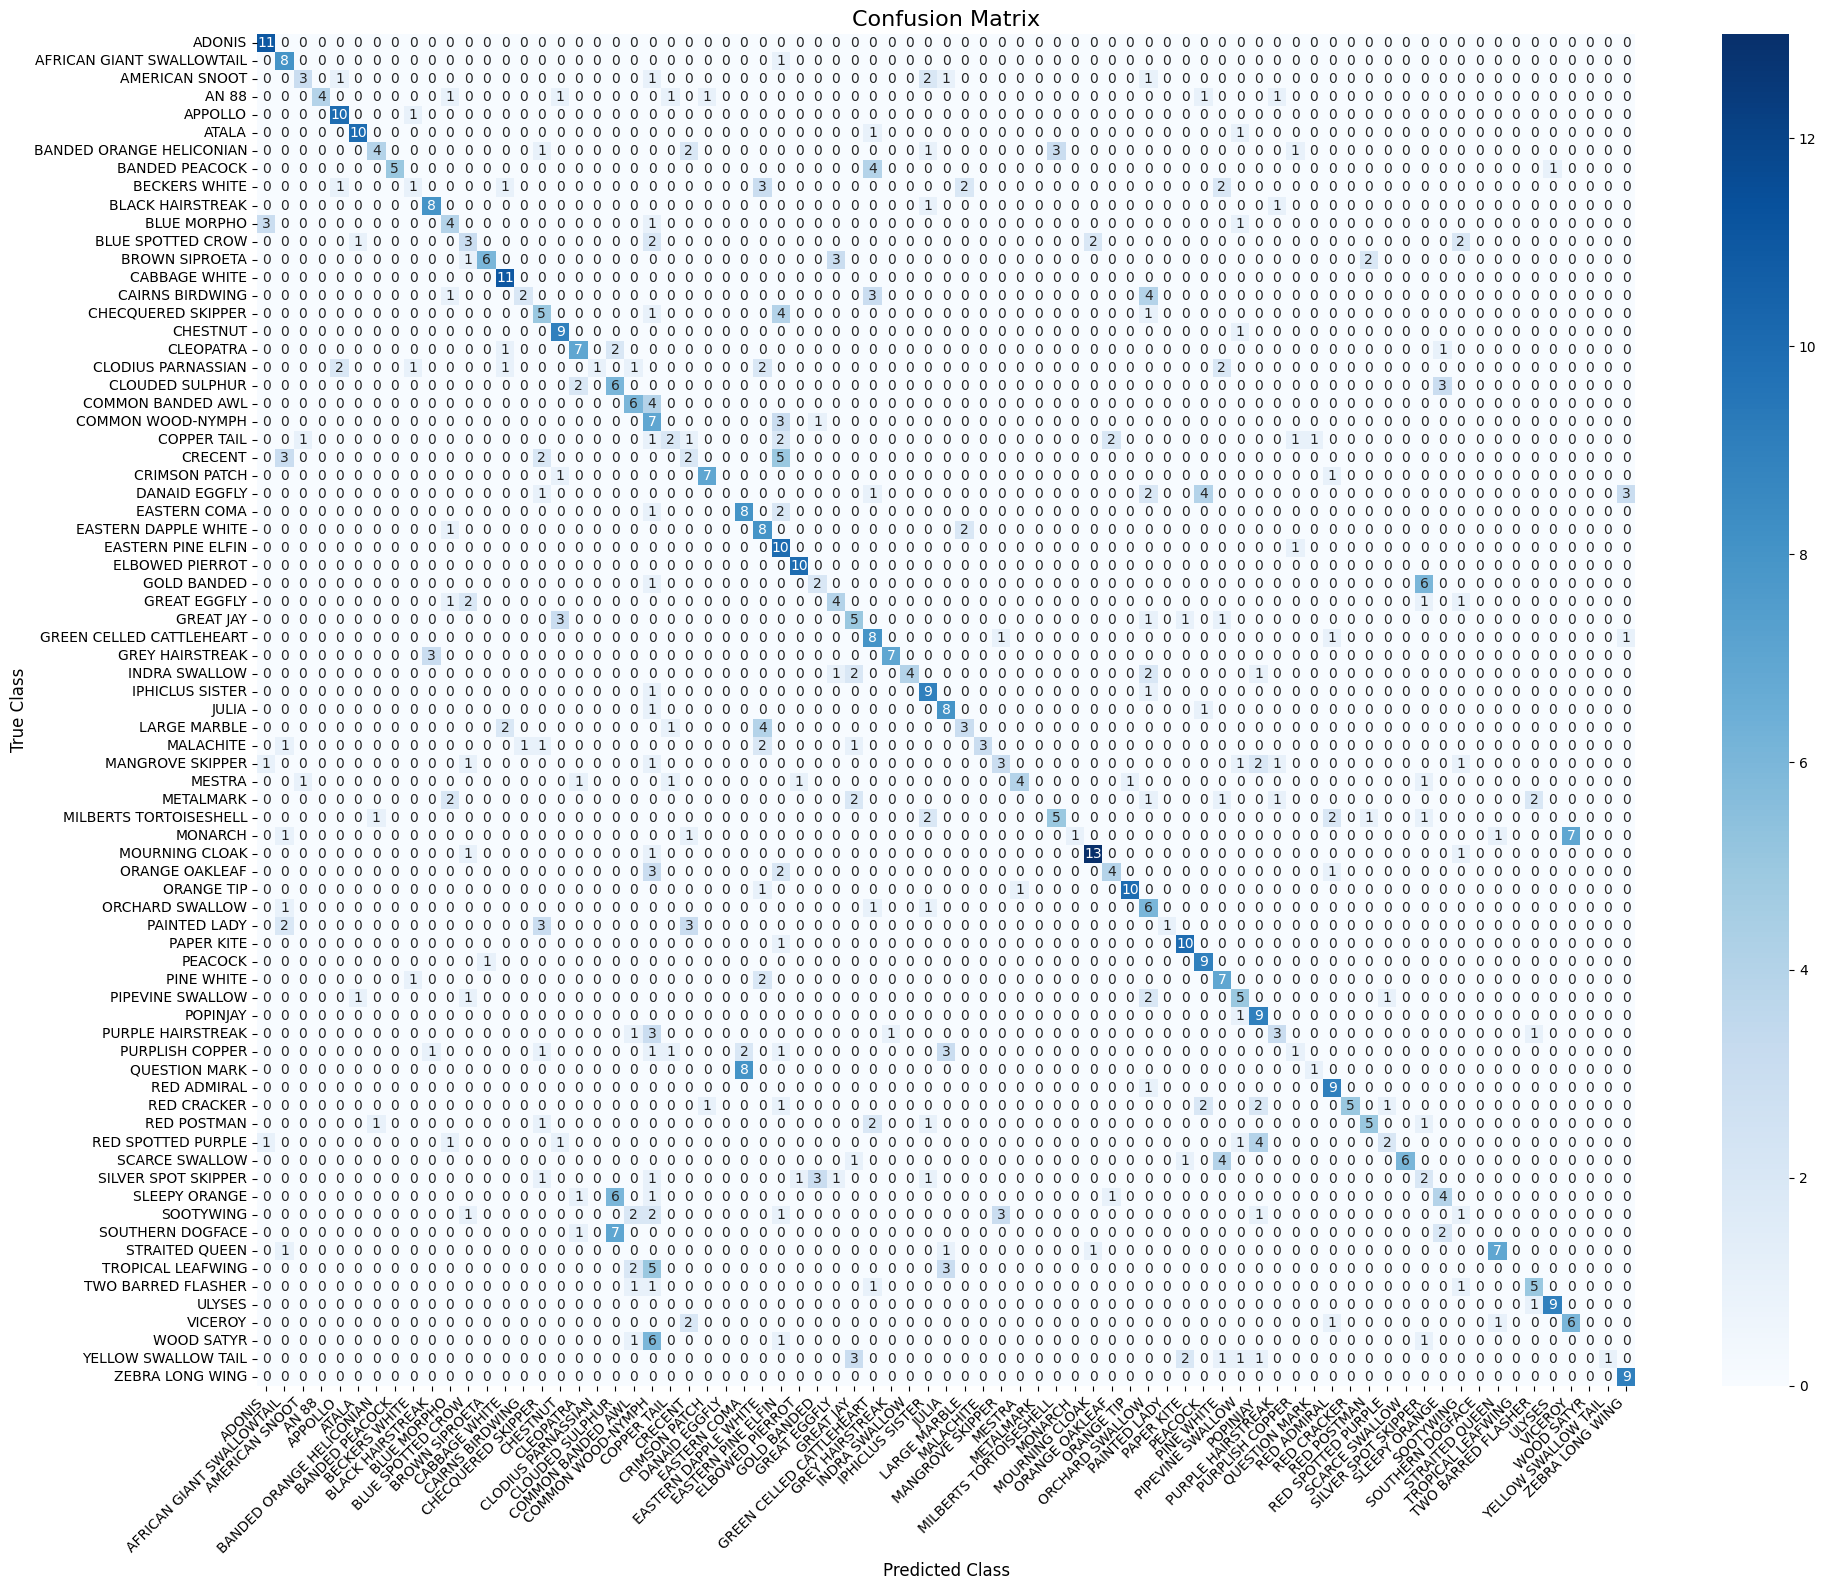

In [23]:
# Evaluate the final model on the Test Set
baseline_results = evaluate_on_test(
    model,
    test_loader, 
    device,
    class_names=test_dataset.classes
)

In [24]:
generate_kaggle_submission(
    model=model,
    test_dir=test_dir,
    transform=data_transform,
    device=device,
    class_names=test_dataset.classes,
    save_name='baseline_submission.csv'
)

Processing 1300 images for the submission...
Success! Submission saved to: /content/drive/MyDrive/AdvancedMachineLearning2/baseline_submission.csv


,filename,label
0,Image_0.jpg,RED ADMIRAL
1,Image_1.jpg,BECKERS WHITE
2,Image_10.jpg,PIPEVINE SWALLOW
3,Image_100.jpg,POPINJAY
4,Image_1000.jpg,GREAT JAY
...,...,...
1295,Image_995.jpg,GREAT JAY
1296,Image_996.jpg,AMERICAN SNOOT
1297,Image_997.jpg,BECKERS WHITE
1298,Image_998.jpg,VICEROY


### Simple Augmentation - TRANSFORMATIONS

In [40]:
from torch.utils.data import ConcatDataset

# ============================================================
# SELECT WORST PERFORMING CLASSES
# ============================================================

worst_classes = baseline_results['worst_classes']

# Estraiamo correttamente i nomi delle specie usando la chiave del dizionario
worst_class_names = [cls_dict['Species Name'] for cls_dict in worst_classes]

print("Worst classes identified for targeted augmentation:")
print(worst_class_names)


# ============================================================
# CREATE DATAFRAME ONLY FOR WORST CLASSES
# ============================================================

worst_df = train_df[
    train_df['label'].isin(worst_class_names)
]


# ============================================================
# AUGMENTED DATASET FOR WORST CLASSES
# ============================================================
# Uses the augmentation transform defined previously.
# ============================================================

# blocco [-1, 1]
worst_dataset_aug = ButterflyDataset(
    df=worst_df,
    img_dir=img_dir,
    transform=train_transform_augmentation
)



# ============================================================
# CONCATENATE:
# - original train dataset [0,1]
# - augmented worst classes [0,1]
# ============================================================

combined_dataset = ConcatDataset([

    train_dataset, # -> [0,1]

    worst_dataset_aug # -> [0,1]

])


# ============================================================
# FINAL TRAINING LOADER
# ============================================================

combined_loader = data.DataLoader(

    combined_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=4,

    pin_memory=True

)


# ============================================================
# 6. DATASET STATISTICS
# ============================================================
print("\n" + "="*40)
print("          DATASET PIPELINE STATISTICS          ")
print("="*40)
print(f"Original training samples: {len(train_dataset)}")
print(f"Number of worst classes: {len(worst_class_names)}")
print(f"Augmented worst-class samples: {len(worst_dataset_aug)}")
print(f"Combined training samples: {len(combined_dataset)}")
print("="*40 + "\n")


export_dataset_to_zip(
    dataset_obj=combined_dataset, 
    train_df=train_df,
    zip_filename="butterfly_dataset_simple_aug",
    drive_folder=DRIVE_FOLDER
)

Worst classes identified for targeted augmentation:
['DANAID EGGFLY', 'METALMARK', 'SOUTHERN DOGFACE', 'TROPICAL LEAFWING', 'WOOD SATYR', 'SOOTYWING', 'PURPLISH COPPER', 'BECKERS WHITE', 'MONARCH', 'CRECENT']

          DATASET PIPELINE STATISTICS          
Original training samples: 3641
Number of worst classes: 10
Augmented worst-class samples: 481
Combined training samples: 4122

Esportazione piatta di 4122 immagini per 'butterfly_dataset_simple_aug'...


100%|██████████| 4122/4122 [00:11<00:00, 350.96it/s]



[INFO] Creato file di indice '/content/temp_butterfly_dataset_simple_aug/train_augmented.csv' con 4122 righe.
Compressione e salvataggio su Google Drive in corso...
Destinazione: MyDrive/AdvancedMachineLearning2/butterfly_dataset_simple_aug.zip
[SUCCESS] Archivio 'butterfly_dataset_simple_aug.zip' pronto su Google Drive!



In [27]:
n_classes = len(train_dataset_augmentation.classes)
print(f"Number of classes: {n_classes}")
model_augmented = BaselineCNN(num_classes=n_classes)
optimizer = optim.Adam(model_augmented.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

num_epochs = 30  
patience = 5   

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
        
history_augmented = train_model(
    model=model_augmented, 
    train_loader=combined_loader, 
    val_loader=val_loader_augmentation, 
    criterion=criterion, 
    optimizer=optimizer, 
    device=device,
    num_epochs=num_epochs,          # Max epochs for training
    patience=patience,              # Early stopping patience (number of epochs with no improvement after which training will be stopped)
    scheduler=scheduler
)

Number of classes: 75
[1/30] Train: Loss = 4.2223 Accuracy = 3.61% | Val: Loss = 4.7074 Accuracy = 2.57% | 
[2/30] Train: Loss = 3.9140 Accuracy = 4.46% | Val: Loss = 4.1081 Accuracy = 4.50% | 
[3/30] Train: Loss = 3.6741 Accuracy = 6.74% | Val: Loss = 4.4163 Accuracy = 6.56% | 
[4/30] Train: Loss = 3.5474 Accuracy = 7.84% | Val: Loss = 3.3376 Accuracy = 11.57% | 
[5/30] Train: Loss = 3.4160 Accuracy = 9.51% | Val: Loss = 3.2239 Accuracy = 11.05% | 
[6/30] Train: Loss = 3.3122 Accuracy = 10.84% | Val: Loss = 3.0744 Accuracy = 14.52% | 
[7/30] Train: Loss = 3.2537 Accuracy = 10.67% | Val: Loss = 3.2770 Accuracy = 11.18% | 
[8/30] Train: Loss = 3.1448 Accuracy = 13.03% | Val: Loss = 2.9534 Accuracy = 14.78% | 
[9/30] Train: Loss = 3.0809 Accuracy = 14.58% | Val: Loss = 3.0679 Accuracy = 15.81% | 
[10/30] Train: Loss = 3.0272 Accuracy = 15.96% | Val: Loss = 2.7605 Accuracy = 22.37% | 
[11/30] Train: Loss = 2.9462 Accuracy = 16.84% | Val: Loss = 2.7578 Accuracy = 19.28% | 
[12/30] Train: L

Evaluating the final model on the Test Set...
Test Accuracy: 54.87%
Macro F1-score: 0.5095

FINAL RESULTS (TEST SET)

                           precision    recall  f1-score   support

                   ADONIS       0.91      0.91      0.91        11
AFRICAN GIANT SWALLOWTAIL       0.50      0.44      0.47         9
           AMERICAN SNOOT       0.18      0.22      0.20         9
                    AN 88       1.00      0.50      0.67        10
                  APPOLLO       0.79      1.00      0.88        11
                    ATALA       0.59      0.83      0.69        12
 BANDED ORANGE HELICONIAN       0.78      0.58      0.67        12
           BANDED PEACOCK       1.00      0.60      0.75        10
            BECKERS WHITE       0.00      0.00      0.00        10
         BLACK HAIRSTREAK       0.57      0.80      0.67        10
              BLUE MORPHO       1.00      0.11      0.20         9
        BLUE SPOTTED CROW       0.00      0.00      0.00        10
          

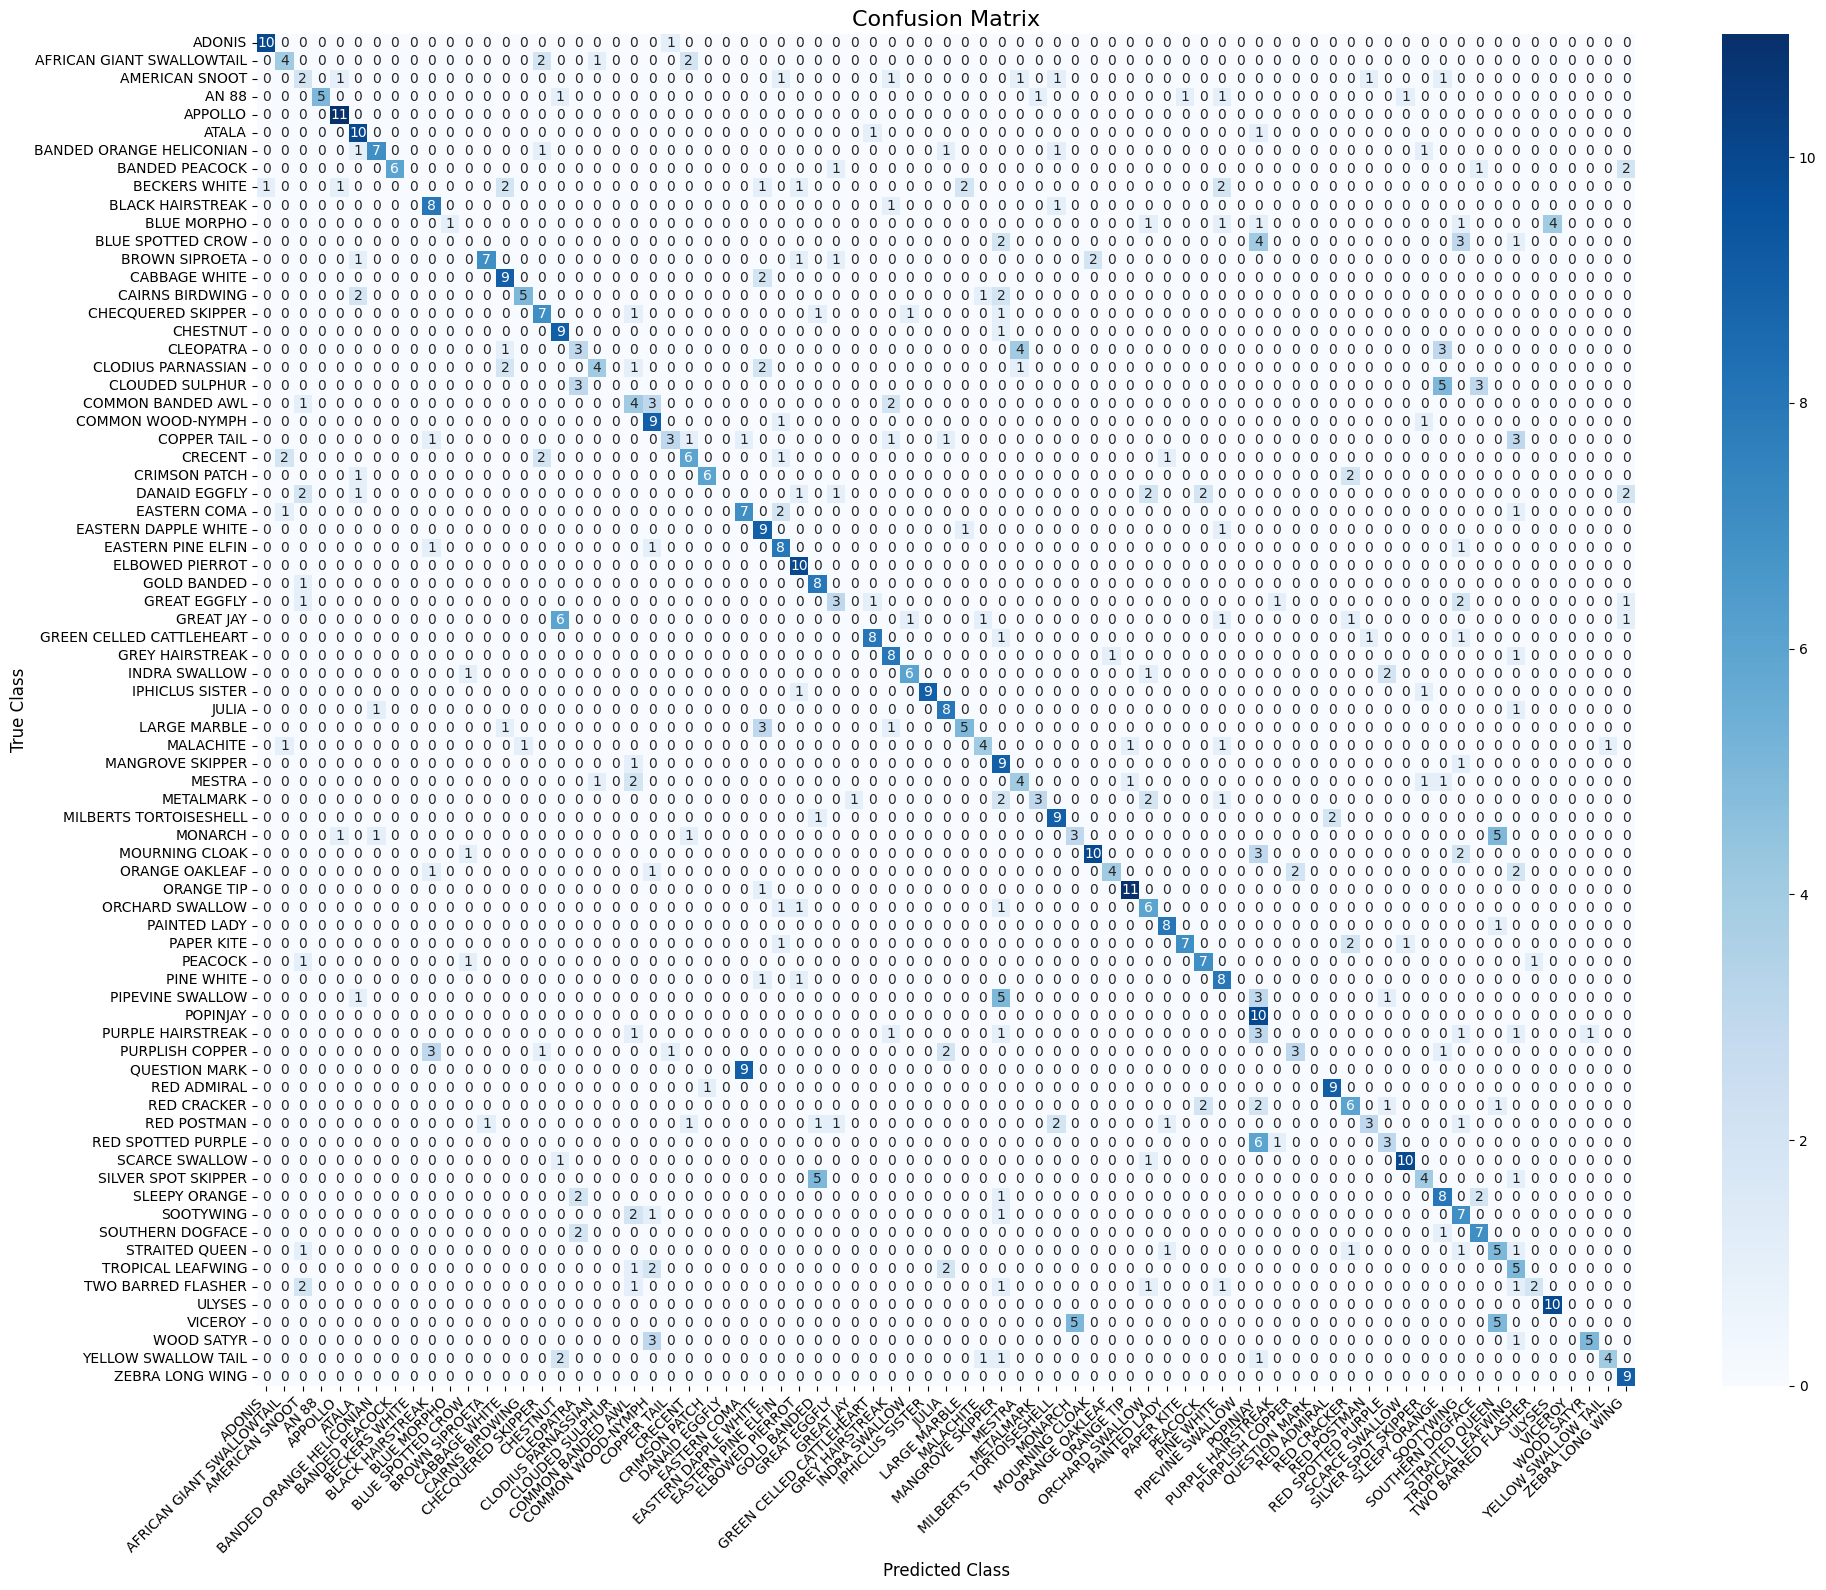

In [30]:
# Evaluate the final model on the Test Set
augmented_results = evaluate_on_test(
    model_augmented,
    test_loader_augmentation,
    device,
    class_names=test_dataset_augmentation.classes
)

In [41]:
generate_kaggle_submission(
    model=model_augmented,
    test_dir=test_dir,
    transform=val_test_transform_augmentation,
    device=device,
    class_names=test_dataset_augmentation.classes,
    save_name='augmented_submission.csv'
)

Processing 1300 images for the submission...
Success! Submission saved to: /content/drive/MyDrive/AdvancedMachineLearning2/augmented_submission.csv


,filename,label
0,Image_0.jpg,RED ADMIRAL
1,Image_1.jpg,APPOLLO
2,Image_10.jpg,POPINJAY
3,Image_100.jpg,POPINJAY
4,Image_1000.jpg,MALACHITE
...,...,...
1295,Image_995.jpg,INDRA SWALLOW
1296,Image_996.jpg,AMERICAN SNOOT
1297,Image_997.jpg,PINE WHITE
1298,Image_998.jpg,MONARCH


### Comparison between original Dataset and Simple Augmentation Approach

                   Model   Accuracy  Macro F1
0               Baseline  50.512821  0.470178
1  Targeted Augmentation  54.871795  0.509547

IMPROVEMENTS
Accuracy Improvement: +4.36%
Macro F1 Improvement: +0.0394


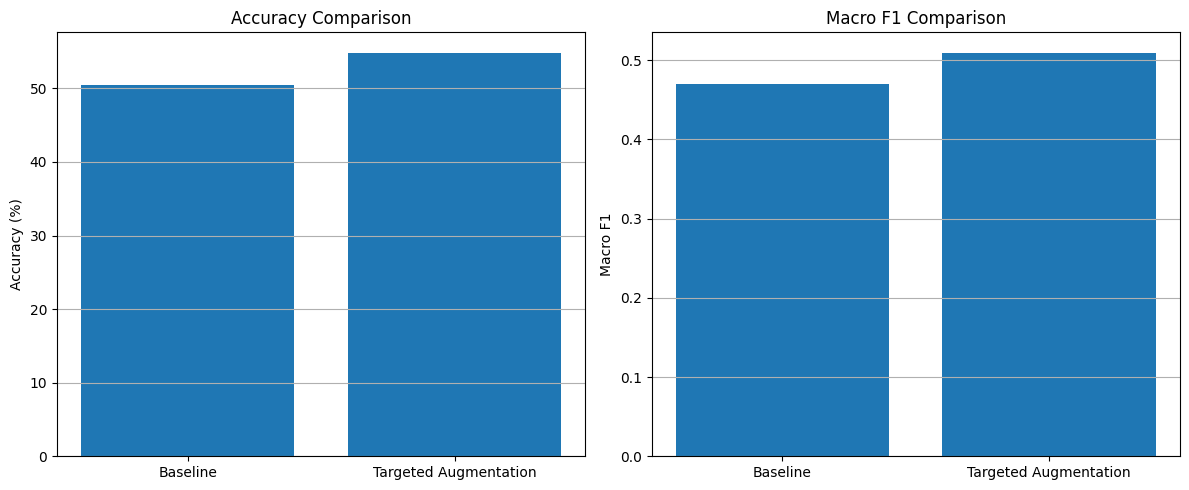

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CONFRONTO BASELINE vs TARGETED AUGMENTATION
# ============================================================

results_summary = pd.DataFrame({
    'Model': ['Baseline', 'Targeted Augmentation'],
    'Accuracy': [
        baseline_results['accuracy'] * 100,
        augmented_results['accuracy'] * 100
    ],
    'Macro F1': [
        baseline_results['macro_f1'],
        augmented_results['macro_f1']
    ]
})

print(results_summary)

# ============================================================
# CALCOLO MIGLIORAMENTI
# ============================================================

acc_improvement = results_summary.loc[1, 'Accuracy'] - results_summary.loc[0, 'Accuracy']
f1_improvement = results_summary.loc[1, 'Macro F1'] - results_summary.loc[0, 'Macro F1']

print("\n==============================")
print("IMPROVEMENTS")
print("==============================")

print(f"Accuracy Improvement: +{acc_improvement:.2f}%")
print(f"Macro F1 Improvement: +{f1_improvement:.4f}")

# ============================================================
# PLOT COMPARISON
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy Plot
axes[0].bar(results_summary['Model'], results_summary['Accuracy'])
axes[0].set_title('Accuracy Comparison')
axes[0].set_ylabel('Accuracy (%)')
axes[0].grid(axis='y')

# Macro F1 Plot
axes[1].bar(results_summary['Model'], results_summary['Macro F1'])
axes[1].set_title('Macro F1 Comparison')
axes[1].set_ylabel('Macro F1')
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()

## Generative Models
We are going to implement:
- Variational Autoencoder (VAE)
- Conditional VAE (cVAE)
- Generative Adversarial Network (GAN)
- Conditional GAN (cGAN)
- Diffusion Model

#### Butterfly Conditional VAE

In [43]:
import torch
import torch.nn as nn

class ButterflyConditionalVAE(nn.Module):
    def __init__(self, num_classes, latent_dim=128, embedded_size=32):
        super().__init__()
        self.latent_dim = latent_dim
        self.embedded_size = embedded_size

        # Embedding condiviso per encoder E decoder
        self.class_embedding = nn.Embedding(num_classes, embedded_size)

        # Proietta l'embedding su un canale spaziale 64×64
        self.enc_label_proj = nn.Linear(embedded_size, 64 * 64)

        # Encoder: ora riceve 4 canali (RGB + canale classe)
        self.encoder = nn.Sequential(
            nn.Conv2d(4, 32, kernel_size=4, stride=2, padding=1),    # -> 32x32
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),   # -> 16x16
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # -> 8x8
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1), # -> 4x4
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Flatten()  # -> 4096
        )

        self.fc_mu     = nn.Linear(4096, latent_dim)
        self.fc_logvar = nn.Linear(4096, latent_dim)

        # Decoder
        self.decoder_embedding = nn.Embedding(num_classes, embedded_size)
        self.decoder_input     = nn.Linear(latent_dim + embedded_size, 4096)

        self.decoder = nn.Sequential(
            nn.Unflatten(1, (256, 4, 4)),

            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1), # -> 8x8
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # -> 16x16
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),   # -> 32x32
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),    # -> 64x64
            nn.Sigmoid()
        )

    def encode(self, x, labels):
        emb = self.class_embedding(labels)           # (B, embedded_size)
        ch  = self.enc_label_proj(emb)               # (B, 64*64)
        ch  = ch.view(-1, 1, 64, 64)                 # (B, 1, 64, 64)
        x_cond = torch.cat([x, ch], dim=1)           # (B, 4, 64, 64)
        h = self.encoder(x_cond)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, labels):
        emb = self.decoder_embedding(labels)
        z_cond = torch.cat([z, emb], dim=1)
        return self.decoder(self.decoder_input(z_cond))

    def forward(self, x, labels):
        mu, logvar = self.encode(x, labels)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z, labels)
        return recon_x, mu, logvar

    def generate_variations(self, real_images, labels, noise_scale=0.1):
        mu, logvar = self.encode(real_images, labels)
        z = mu + noise_scale * torch.randn_like(mu)
        return self.decode(z, labels)

    def reconstruct_images(self, real_images, labels):
        mu, logvar = self.encode(real_images, labels)
        return self.decode(mu, labels)

    def sample(self, num_samples, labels, device):
        z = torch.randn(num_samples, self.latent_dim).to(device)
        return self.decode(z, labels)

In [44]:
def vae_loss_function(recon_x, x, mu, logvar, beta = 0.001):
    
    # Reconstruction Loss: Measures how well the model reconstructs the input image.
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum') / x.size(0)  # normalized by batch size
    
    # KL Divergence: Acts as a regularizer, pushing the latent distribution toward N(0, 1)[cite: 74, 83].
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    kl_loss = kl_loss / x.size(0)  # normalized by batch size

    # Total Loss: Combines the two objectives using the 'beta' hyperparameter.
    total_loss = recon_loss + beta * kl_loss  # normalized by batch size
    
    return total_loss, recon_loss, kl_loss

### Training Loop for VAE

In [45]:
def train_vae(model, dataloader, optimizer, beta=0.001,  num_epochs=30):
    
    model = model.to(device)
    history = {
        'total_loss': [],
        'recon_loss': [],
        'kl_loss': []
    }

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=3
    )

    best_loss = float('inf')
    
    
    for epoch in range(num_epochs):

        model.train()

        total_loss = 0
        train_recon_loss = 0
        train_kl_loss = 0

        for x, labels in dataloader:
            x = x.to(device)
            labels = labels.to(device)

            # The model returns the reconstruction, latent mean (mu), and log-variance
            recon_x, mu, logvar = model(x, labels)

            # LOSS CALCULATION
            # Compute the weighted ELBO (Evidence Lower Bound) loss
            loss, recon_loss, kl_loss = vae_loss_function(recon_x, x, mu, logvar, beta=beta)

            #Backpropagation and update weights
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * x.size(0) 
            train_recon_loss += recon_loss.item() * x.size(0)
            train_kl_loss += kl_loss.item() * x.size(0)
        
        n = len(dataloader.dataset)
        avg_total = total_loss / n
        avg_recon = train_recon_loss / n
        avg_kl = train_kl_loss / n

        history['total_loss'].append(avg_total)
        history['recon_loss'].append(avg_recon)
        history['kl_loss'].append(avg_kl)

        scheduler.step(avg_total)

        if avg_total < best_loss:

            best_loss = avg_total

            torch.save(
                model.state_dict(),
                "best_vae.pth"
            )

        if (epoch + 1) % 5 == 0:

            plot_generated_variations(
                vae_model=model,
                dataloader=dataloader,
                device=device,
                num_examples=6,
                noise_scale=0.1
            )
        
        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_total:.4f} (Recon: {avg_recon:.4f}, KL: {avg_kl:.4f})")
    
    return history


In [46]:
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np
import torch


def plot_generated_variations(vae_model, dataloader, device, num_examples=8, noise_scale=0.1):

    vae_model.eval()

    with torch.no_grad():

        # Prendi un batch reale
        real_images, labels = next(iter(dataloader))

        real_images = real_images[:num_examples].to(device)
        labels = labels[:num_examples].to(device)

        # Genera variazioni realistiche
        generated = vae_model.generate_variations(
            real_images,
            labels,
            noise_scale=noise_scale
        )

        # CONCATENA:
        # prima riga = reali
        # seconda riga = generate
        comparison = torch.cat([
            real_images.cpu(),
            generated.cpu()
        ])

        grid = vutils.make_grid(
            comparison,
            nrow=num_examples,
            padding=2,
            normalize=True
        )

        plt.figure(figsize=(20, 5))

        plt.imshow(
            np.transpose(grid.numpy(), (1, 2, 0))
        )

        plt.axis('off')

        plt.title(
            "Top: Real Images | Bottom: Generated Variations"
        )

        plt.show()

Number of classes: 75
Epoch 1/30 - Loss: 7894.8735 (Recon: 7890.6931, KL: 4180.4409)
Epoch 2/30 - Loss: 7447.0805 (Recon: 7444.6237, KL: 2456.7266)
Epoch 3/30 - Loss: 7336.7498 (Recon: 7334.4894, KL: 2260.3858)
Epoch 4/30 - Loss: 7278.5249 (Recon: 7276.3560, KL: 2168.8453)


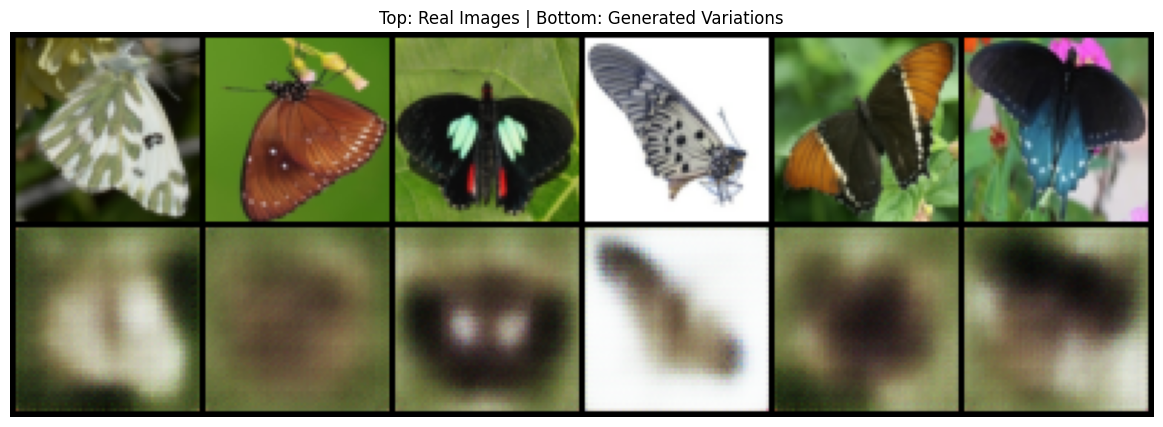

Epoch 5/30 - Loss: 7223.7568 (Recon: 7221.9739, KL: 1782.9177)
Epoch 6/30 - Loss: 7185.4835 (Recon: 7183.8250, KL: 1658.4553)
Epoch 7/30 - Loss: 7111.9068 (Recon: 7110.2213, KL: 1685.5865)
Epoch 8/30 - Loss: 7064.2354 (Recon: 7062.6067, KL: 1628.6920)
Epoch 9/30 - Loss: 7023.8169 (Recon: 7022.1927, KL: 1624.1942)


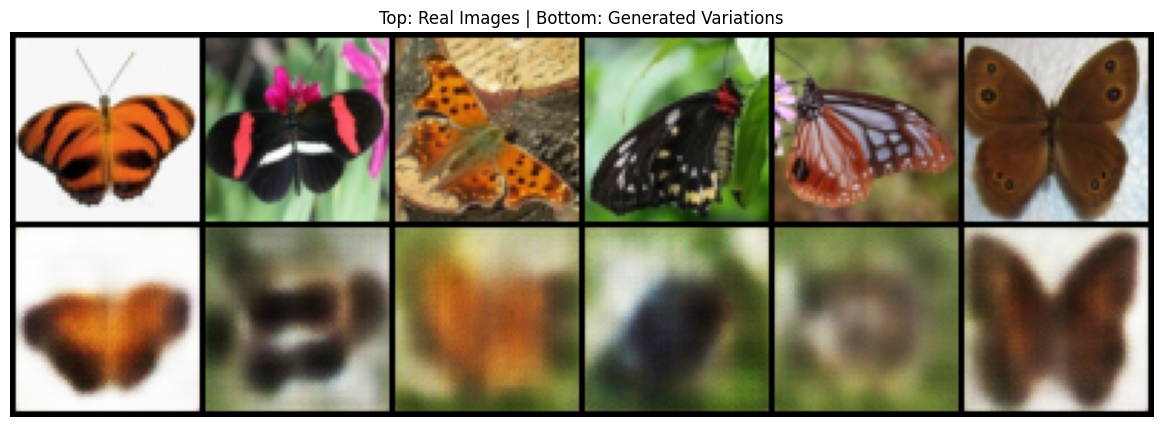

Epoch 10/30 - Loss: 7001.8273 (Recon: 7000.2175, KL: 1609.8659)
Epoch 11/30 - Loss: 6978.7433 (Recon: 6977.1412, KL: 1602.1471)
Epoch 12/30 - Loss: 6954.1334 (Recon: 6952.5588, KL: 1574.6485)
Epoch 13/30 - Loss: 6941.8600 (Recon: 6940.2787, KL: 1581.3219)
Epoch 14/30 - Loss: 6924.2027 (Recon: 6922.6004, KL: 1602.2961)


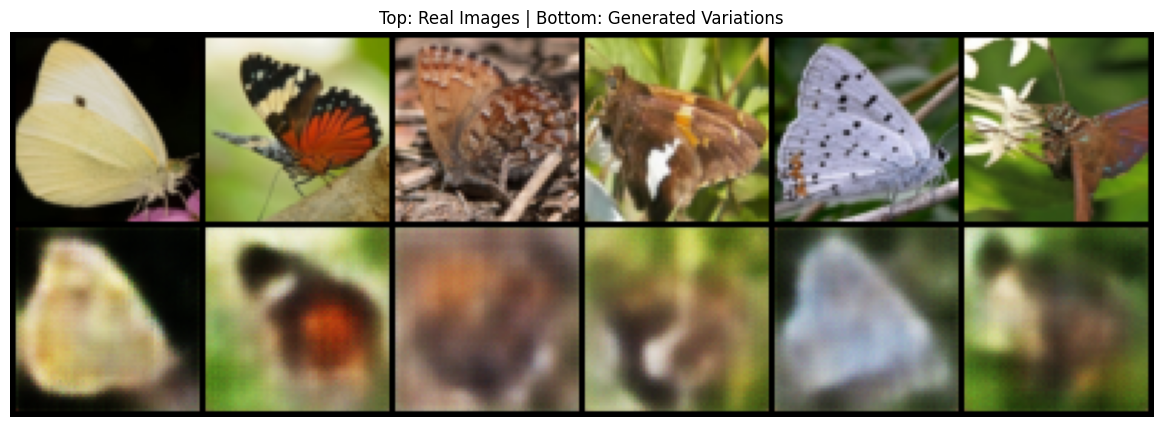

Epoch 15/30 - Loss: 6910.8566 (Recon: 6909.2482, KL: 1608.4849)
Epoch 16/30 - Loss: 6900.6318 (Recon: 6899.0293, KL: 1602.4878)
Epoch 17/30 - Loss: 6884.7271 (Recon: 6883.1319, KL: 1595.2312)
Epoch 18/30 - Loss: 6877.2307 (Recon: 6875.6382, KL: 1592.5844)
Epoch 19/30 - Loss: 6869.8276 (Recon: 6868.2294, KL: 1598.2257)


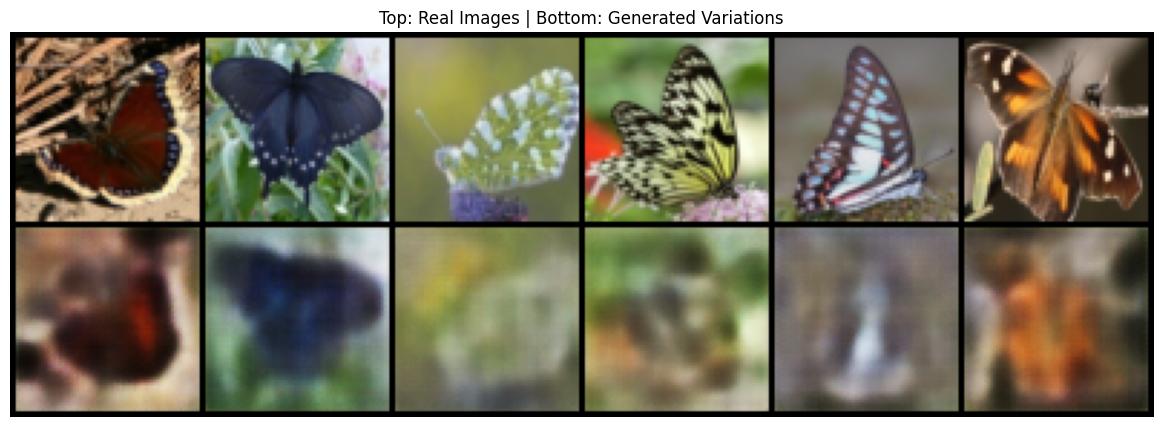

Epoch 20/30 - Loss: 6854.7981 (Recon: 6853.1904, KL: 1607.7349)
Epoch 21/30 - Loss: 6852.6501 (Recon: 6851.0378, KL: 1612.2673)
Epoch 22/30 - Loss: 6842.7145 (Recon: 6841.1093, KL: 1605.1597)
Epoch 23/30 - Loss: 6838.3151 (Recon: 6836.7054, KL: 1609.6646)
Epoch 24/30 - Loss: 6825.4743 (Recon: 6823.8460, KL: 1628.3476)


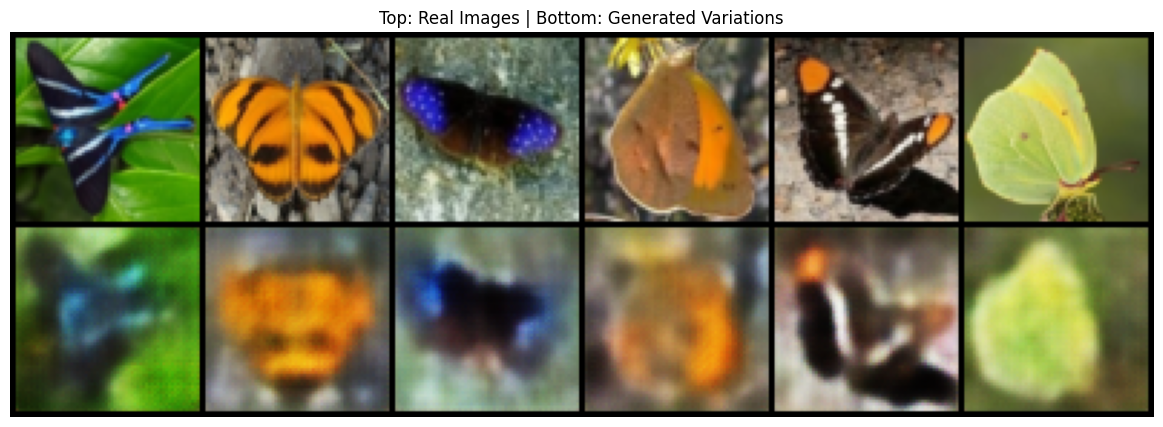

Epoch 25/30 - Loss: 6832.4072 (Recon: 6830.7763, KL: 1630.8700)
Epoch 26/30 - Loss: 6818.1694 (Recon: 6816.5165, KL: 1652.8511)
Epoch 27/30 - Loss: 6812.2865 (Recon: 6810.6475, KL: 1639.0071)
Epoch 28/30 - Loss: 6806.6576 (Recon: 6805.0329, KL: 1624.6929)
Epoch 29/30 - Loss: 6804.7305 (Recon: 6803.1010, KL: 1629.4565)


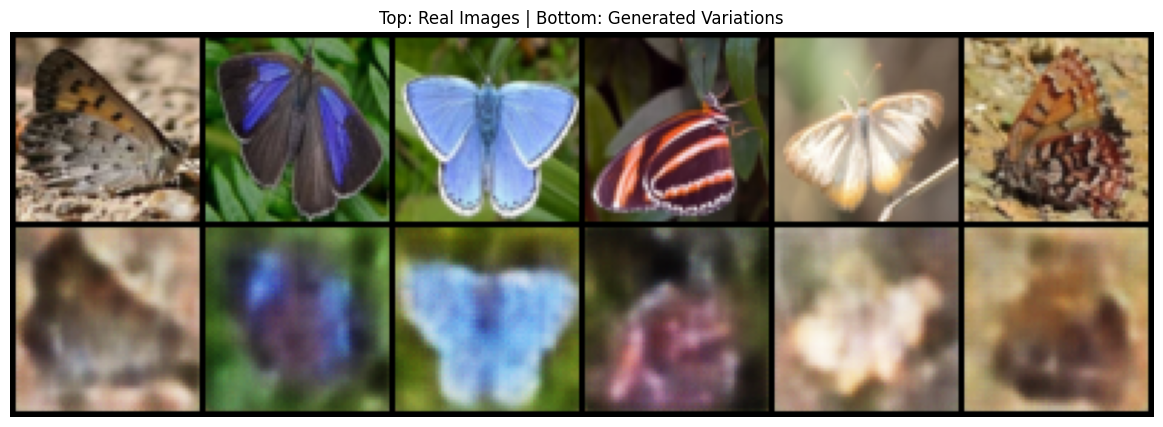

Epoch 30/30 - Loss: 6799.5796 (Recon: 6797.9563, KL: 1623.3093)

Metriche generative: cVAE


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 393MB/s]


FID Score: 359.9871  (↓ meglio)
Inception Score: 1.2422 ± 0.0171  (↑ meglio)
SSIM Score: 0.1767  (↑ meglio, max 1.0)


In [47]:
n_classes = len(train_dataset_augmentation.classes)
print(f"Number of classes: {n_classes}")


"""# Loader dedicato al VAE con immagini 64x64
vae_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

vae_dataset = ButterflyDataset(df=train_df, img_dir=img_dir, transform=vae_transform)
vae_loader  = data.DataLoader(vae_dataset, batch_size=64, shuffle=True)"""

# Inizializziamo il VAE con uno spazio latente di 128 dimensioni
vae = ButterflyConditionalVAE(num_classes=n_classes, latent_dim=128)

vae_optimizer = optim.Adam(vae.parameters(), lr=0.001)

# Lo addestriamo usando le immagini reali del train_loader
vae_history = train_vae(
    model=vae, 
    dataloader=gen_loader, 
    optimizer=vae_optimizer, 
    beta=0.001,
    num_epochs=30
)

# 2. Metriche VAE 
res_vae = evaluate_all_generative_metrics(
    model=vae,
    model_name='cVAE',
    real_loader=gen_loader,
    device=device,
    n_samples=2000,
    n_classes=n_classes,
    model_type='vae'
)
results_list = [res_vae]

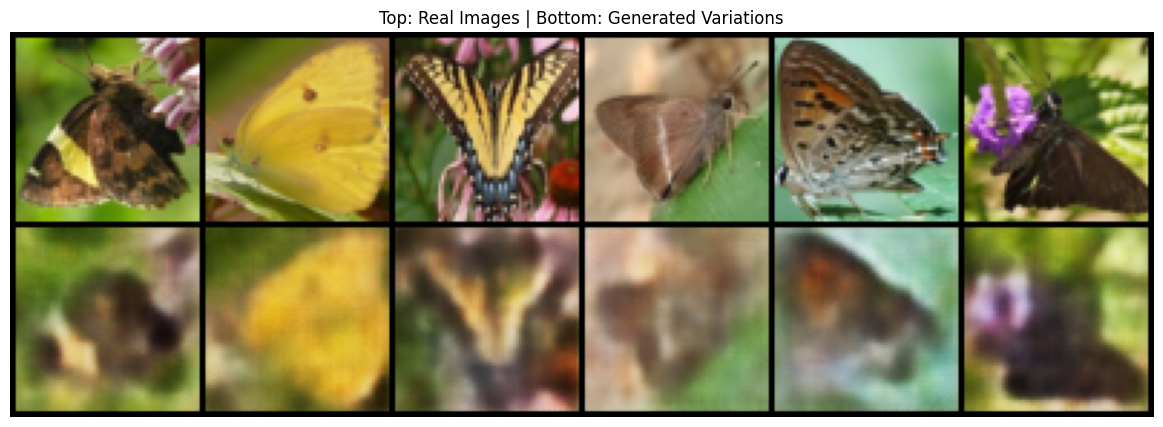

In [48]:
plot_generated_variations(
    vae_model=vae,
    dataloader=train_loader,
    device=device,
    num_examples=6,
    noise_scale=0.01
)

In [49]:
worst_class_names = [
    cls for cls, score in worst_classes
]

print(worst_class_names)

worst_df = train_df[
    train_df['label'].isin(worst_class_names)
]

print(worst_df.head())

print(f"Number of samples in worst classes: {len(worst_df)}")

ValueError: too many values to unpack (expected 2)

## Synthetic Augmentation Filtered

In [50]:
worst_dataset = ButterflyDataset(
    df=worst_df,
    img_dir=img_dir,
    transform=data_transform
)

worst_loader = data.DataLoader(
    worst_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


In [ ]:
import torch
import numpy as np
import gc
from torch.utils.data import TensorDataset, ConcatDataset, Dataset

# Forces Python's built-in garbage collector to destroy unreferenced objects, releasing system RAM immediately.
gc.collect()
torch.cuda.empty_cache()

# ============================================================
# 1. FUNZIONE: SELEZIONE TOP-K CHUNK-BY-CHUNK (Sicura per la GPU)
# ============================================================
def select_top_k_from_cvae(classifier, synthetic_images, labels, device, k_per_class=20):
    """
    Seleziona i migliori K campioni per classe elaborandoli a piccoli batch 
    sulla GPU per evitare OutOfMemory.
    """
    classifier.eval()
    selected_images = []
    selected_labels = []
    
    with torch.no_grad():
        # Calcoliamo le probabilità processando le immagini a piccoli blocchi
        all_probs = []
        eval_batch_size = 64 # Processiamo solo 64 immagini alla volta sulla GPU
        
        for i in range(0, len(synthetic_images), eval_batch_size):
            # slices out 64 synthetic images resting on the CPU and transfers 
            # only those 64 onto the active GPU hardware.
            chunk_imgs = synthetic_images[i:i+eval_batch_size].to(device)
            # feeds the chunk into your baseline network to obtain raw class scores (logits).
            outputs = classifier(chunk_imgs)
            probs = torch.softmax(outputs, dim=1).cpu() # Riportiamo subito su CPU
            all_probs.append(probs)
            
        # concatenates all chunk probability arrays back into a single matrix.
        probs = torch.cat(all_probs, dim=0)
        
        # detects every target ID present in the label array
        # (i.e., your isolated weak classes) and casts them into a NumPy iterable list.
        unique_classes = torch.unique(labels).numpy()
        
        for cls in unique_classes:
            # Creates a boolean index array to filter data 
            # belonging exclusively to the current class iteration.
            mask = (labels == cls)
            if not mask.any():
                continue

            # Applies the mask to isolate only the current 
            # class's generated images, targets, and calculated network probabilities.    
            cls_imgs = synthetic_images[mask]
            cls_lbls = labels[mask]
            cls_probs = probs[mask]
            
            # slices out the exact probability index that your baseline 
            # assigned to the correct ground-truth target. This acts as a quality metric.
            correct_confidences = cls_probs[:, cls]
            
            current_k = min(k_per_class, len(correct_confidences))
            # sorts the confidence scores and returns the top-K values 
            # alongside their exact element indexes (top_indices). 
            # This isolates the highest-fidelity images.
            top_values, top_indices = torch.topk(correct_confidences, k=current_k)
            
            selected_images.append(cls_imgs[top_indices])
            selected_labels.append(cls_lbls[top_indices])
            
            print(f"Classe {cls} -> Selezionati i migliori {current_k} campioni. Miglior confidenza: {top_values[0].item():.4f}")
            
    return torch.cat(selected_images, dim=0), torch.cat(selected_labels, dim=0)


# ============================================================
# GENERATION CYCLE
# creation of a large pool of synthetic images for the worst classes, 
# storing them in RAM to avoid GPU OOM, 
# and then selecting the top-K best ones using the function above.
# ============================================================
raw_synthetic_images = []
synthetic_labels = []

# It tells the pipeline to parse the complete weak class dataset 
# loader 15 times over to create a large pool of raw candidate data.
MOLTIPLICATORE = 15 

vae.eval()
with torch.no_grad():
    for _ in range(MOLTIPLICATORE):
        
        # Iterates through the batch generator containing only real samples 
        # belonging to your designated 10 worst classes.
        for images, labels in worst_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            # generate customized visual mutations on GPU
            generated = vae.generate_variations(real_images=images, labels=labels)
            
            
            raw_synthetic_images.append(generated.detach().cpu())
            synthetic_labels.append(labels.detach().cpu())

# assembles the collection of small CPU chunks into one consolidated 
# raw matrix holding thousands of synthetic frames.
raw_synthetic_images = torch.cat(raw_synthetic_images, dim=0)
synthetic_labels = torch.cat(synthetic_labels, dim=0)

print(f"Campioni generati totali accumulati in RAM: {len(raw_synthetic_images)}")

# Svuotiamo la cache della GPU prima della selezione
torch.cuda.empty_cache()


# ============================================================
# Apply the top-K selection function to filter out only the best synthetic samples
# ============================================================

# keep only the top 80 cleanest frames per class.
K_SCELTO = 80

filtered_vae_images, filtered_vae_labels = select_top_k_from_cvae(
    classifier=model,                      # baseline CNN for image quality evaluation
    synthetic_images=raw_synthetic_images, 
    labels=synthetic_labels,               
    k_per_class=K_SCELTO,
    device=device
)

print(f"\nTotale campioni cVAE selezionati con cura: {len(filtered_vae_images)}")

# Pulizia finale della GPU prima del training
torch.cuda.empty_cache()
gc.collect()


# ============================================================
# 4. CREAZIONE DATASET UNITO E RIADDESTRAMENTO
# ============================================================

# Pipeline geometrica speculare applicata anche alle immagini sintetiche del VAE
vae_augmentation_pipeline = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=30)
])

FATTORE_MOLTIPLICAZIONE = 3
# Concatenazione deterministica 1:1 dei campioni VAE filtrati
repeated_vae_images = torch.cat([filtered_vae_images] * FATTORE_MOLTIPLICAZIONE, dim=0)
repeated_vae_labels = torch.cat([filtered_vae_labels] * FATTORE_MOLTIPLICAZIONE, dim=0)

vae_synthetic_dataset = AugmentedTensorDataset(
    repeated_vae_images, 
    repeated_vae_labels, 
    transform=vae_augmentation_pipeline
)

# IL SUPER DATASET BILANCIATO: Uniamo i tre mondi anche per il cVAE
cvae_augmented_dataset = ConcatDataset([
    train_dataset,         # 1. I dati reali di partenza
    worst_dataset_aug,     # 2. Le immagini REALI delle 10 classi peggiori aumentate geometricamente
    vae_synthetic_dataset  # 3. Le immagini del cVAE filtrate e ulteriormente aumentate in RAM
])

print(f"Dimensione finale del nuovo Dataset Ibrido Aumentato (cVAE): {len(cvae_augmented_dataset)}")

# Save the dataset to a ZIP file and upload to Google Drive
# Esportazione e salvataggio dello ZIP del cVAE su Google Drive
export_dataset_to_zip(
    dataset_obj=cvae_augmented_dataset,  # Assicurati che sia il nome della variabile del tuo dataset cVAE combinato
    train_df=train_df, 
    drive_folder=DRIVE_FOLDER, 
    zip_filename="butterfly_dataset_cVAE"
)

cvae_augmented_loader = data.DataLoader(cvae_augmented_dataset, batch_size=BATCH_SIZE, shuffle=True)

Campioni generati totali accumulati in RAM: 7215
Classe 0 -> Selezionati i migliori 80 campioni. Miglior confidenza: 0.0055
Classe 1 -> Selezionati i migliori 80 campioni. Miglior confidenza: 0.0004
Classe 2 -> Selezionati i migliori 80 campioni. Miglior confidenza: 0.1912
Classe 3 -> Selezionati i migliori 80 campioni. Miglior confidenza: 0.0001
Classe 4 -> Selezionati i migliori 80 campioni. Miglior confidenza: 0.0007
Classe 5 -> Selezionati i migliori 80 campioni. Miglior confidenza: 0.0081
Classe 6 -> Selezionati i migliori 80 campioni. Miglior confidenza: 0.0004
Classe 7 -> Selezionati i migliori 80 campioni. Miglior confidenza: 0.0302
Classe 8 -> Selezionati i migliori 80 campioni. Miglior confidenza: 0.0314
Classe 9 -> Selezionati i migliori 80 campioni. Miglior confidenza: 0.0167

Totale campioni cVAE selezionati con cura: 800
Dimensione finale del nuovo Dataset Ibrido Aumentato (cVAE): 6522
Esportazione piatta di 6522 immagini per 'butterfly_dataset_cVAE'...


100%|██████████| 6522/6522 [00:16<00:00, 391.38it/s]



[INFO] Creato file di indice '/content/temp_butterfly_dataset_cVAE/train_augmented.csv' con 6522 righe.
Compressione e salvataggio su Google Drive in corso...
Destinazione: MyDrive/AdvancedMachineLearning2/butterfly_dataset_cVAE.zip
[SUCCESS] Archivio 'butterfly_dataset_cVAE.zip' pronto su Google Drive!



In [ ]:
# Initialization and training of the new CNN model on the augmented dataset
augmented_model = BaselineCNN(num_classes=n_classes).to(device)
optimizer = optim.Adam(augmented_model.parameters(), lr=0.0005, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4)

print("\nAvvio addestramento della CNN...")
augmented_history = train_model(
    model=augmented_model,
    train_loader=cvae_augmented_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=num_epochs,
    patience=patience,
    scheduler=scheduler
)


Avvio addestramento della CNN...
[1/30] Train: Loss = 3.3489 Accuracy = 16.01% | Val: Loss = 4.1323 Accuracy = 3.08% | 
[2/30] Train: Loss = 2.7538 Accuracy = 26.08% | Val: Loss = 3.4597 Accuracy = 8.23% | 
[3/30] Train: Loss = 2.4429 Accuracy = 32.87% | Val: Loss = 3.2060 Accuracy = 15.55% | 
[4/30] Train: Loss = 2.2497 Accuracy = 37.78% | Val: Loss = 3.0014 Accuracy = 16.71% | 
[5/30] Train: Loss = 2.1235 Accuracy = 41.21% | Val: Loss = 2.8301 Accuracy = 19.41% | 
[6/30] Train: Loss = 2.0422 Accuracy = 42.87% | Val: Loss = 2.8561 Accuracy = 20.69% | 
[7/30] Train: Loss = 1.9360 Accuracy = 44.77% | Val: Loss = 2.6263 Accuracy = 24.81% | 
[8/30] Train: Loss = 1.8647 Accuracy = 46.20% | Val: Loss = 2.9544 Accuracy = 17.48% | 
[9/30] Train: Loss = 1.7863 Accuracy = 49.31% | Val: Loss = 2.5124 Accuracy = 28.28% | 
[10/30] Train: Loss = 1.6898 Accuracy = 50.29% | Val: Loss = 2.3767 Accuracy = 31.88% | 
[11/30] Train: Loss = 1.5922 Accuracy = 53.43% | Val: Loss = 2.5709 Accuracy = 28.02% |

Valutazione del modello aumentato con Top-K cVAE sul Test Set...
Evaluating the final model on the Test Set...
Test Accuracy: 60.26%
Macro F1-score: 0.5868

FINAL RESULTS (TEST SET)

                           precision    recall  f1-score   support

                   ADONIS       1.00      0.82      0.90        11
AFRICAN GIANT SWALLOWTAIL       1.00      0.44      0.62         9
           AMERICAN SNOOT       0.14      0.11      0.12         9
                    AN 88       1.00      0.50      0.67        10
                  APPOLLO       0.77      0.91      0.83        11
                    ATALA       0.80      0.67      0.73        12
 BANDED ORANGE HELICONIAN       0.82      0.75      0.78        12
           BANDED PEACOCK       1.00      0.60      0.75        10
            BECKERS WHITE       0.50      0.40      0.44        10
         BLACK HAIRSTREAK       0.83      0.50      0.62        10
              BLUE MORPHO       0.41      0.78      0.54         9
        BLUE

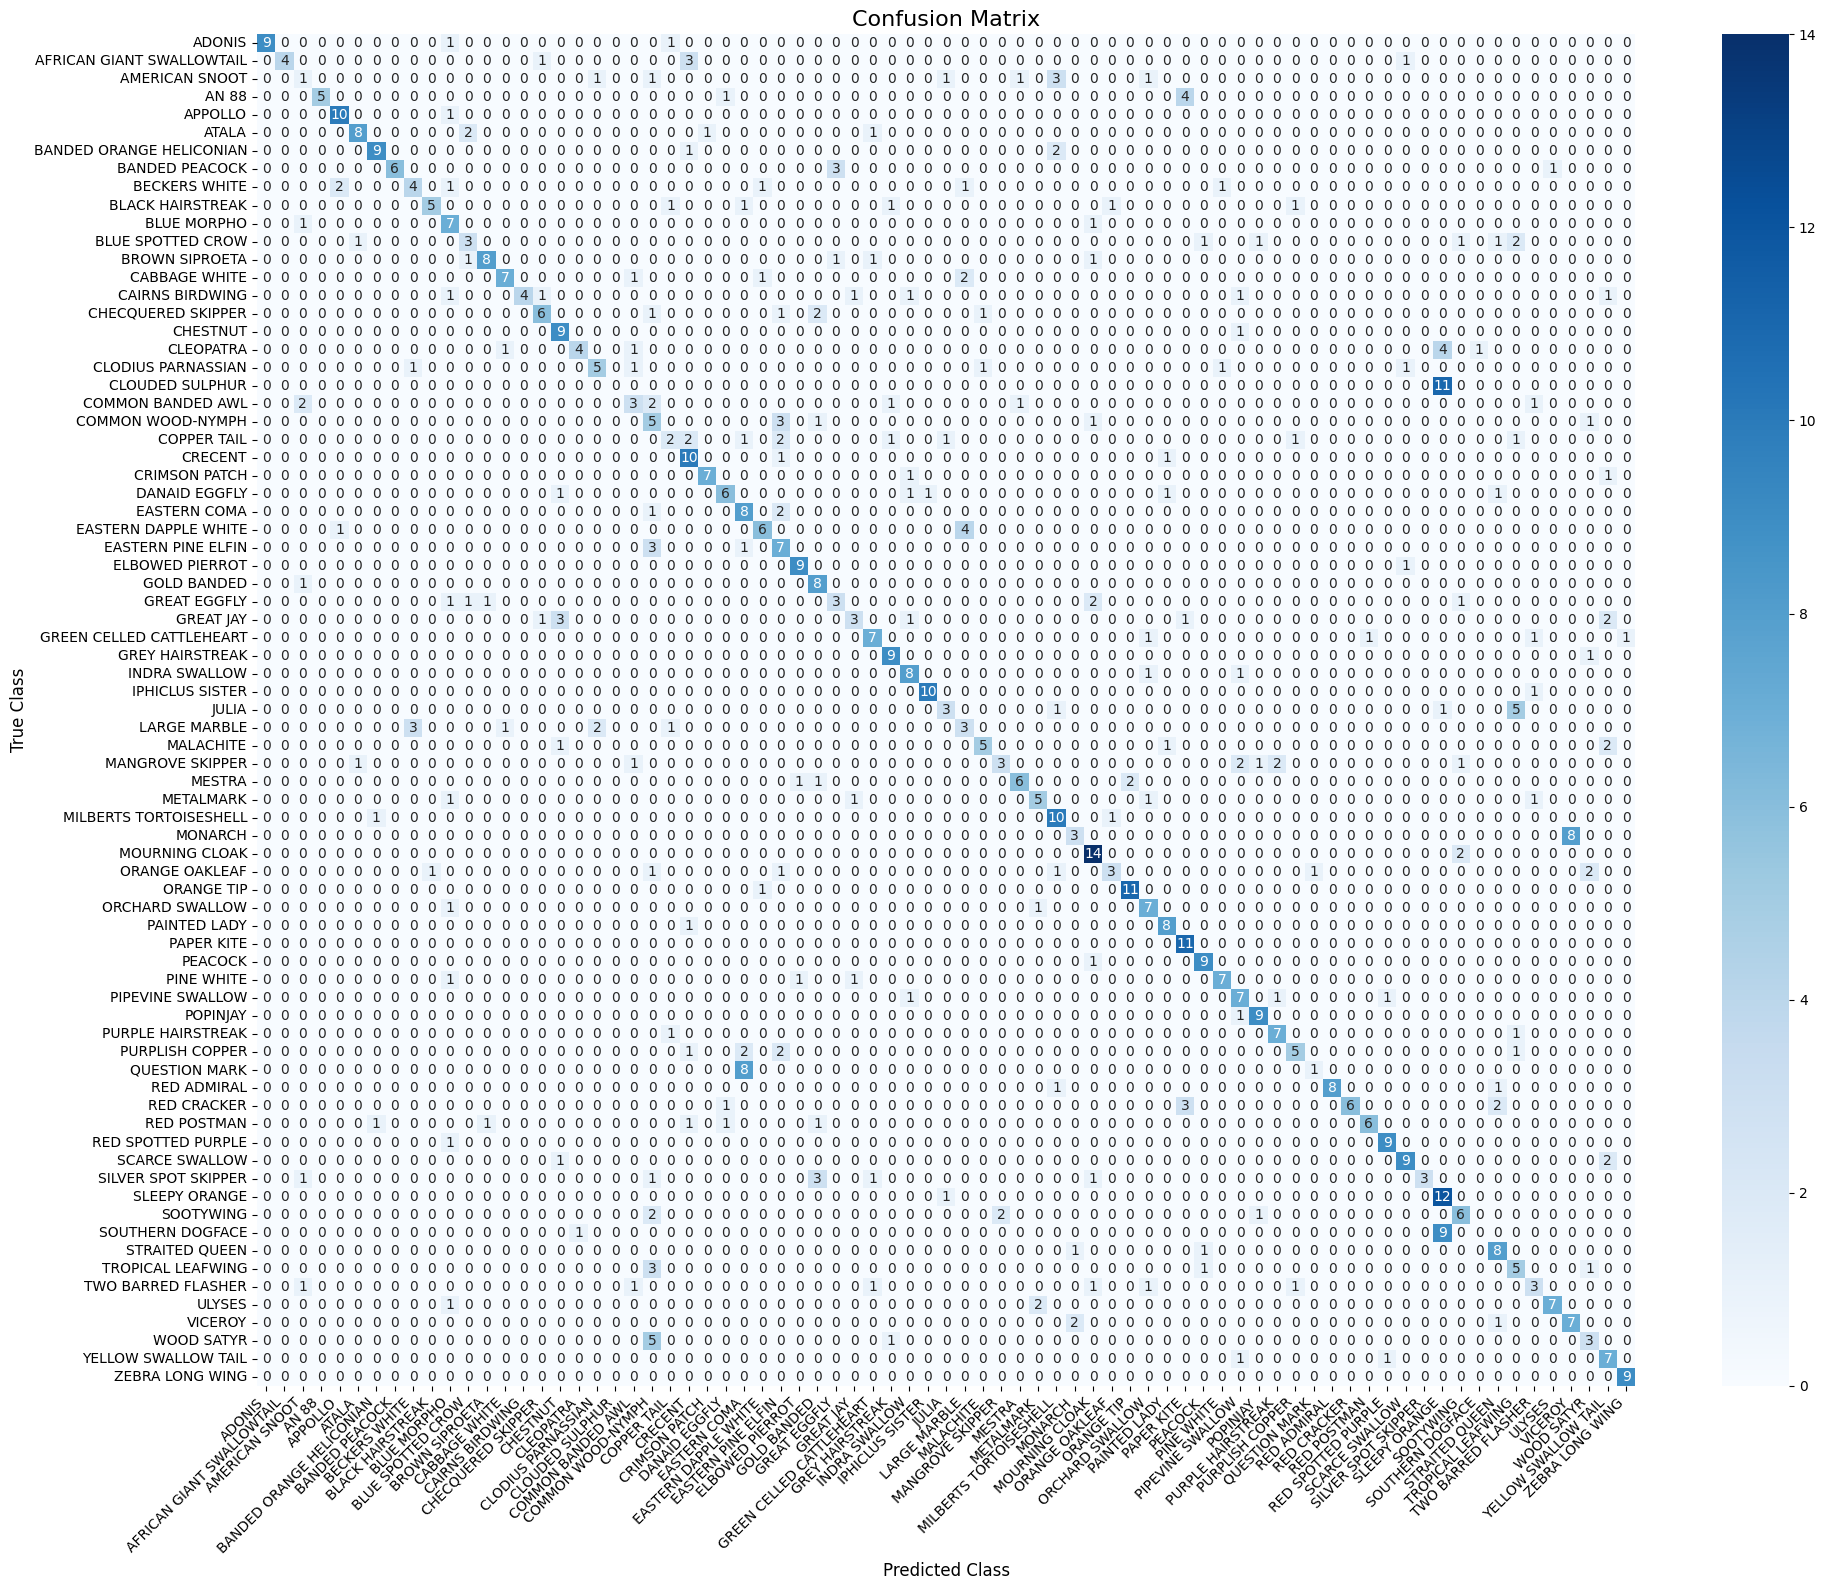

In [ ]:
print("Valutazione del modello aumentato con Top-K cVAE sul Test Set...")

vae_topk_results = evaluate_on_test(
    model=augmented_model,              # Il modello appena addestrato con i Top-K
    test_loader=test_loader,            # Il test loader originale in [0, 1]
    device=device,
    class_names=train_dataset.classes   # Le classi del dataset originale
)

In [ ]:
submission_df = generate_kaggle_submission(
    model=augmented_model,
    test_dir=test_dir,
    transform=gen_transform,  # Trasformazione originale per il test
    device=device,
    class_names=train_dataset.classes,
    save_name='vae_augmented_submission.csv'
)


Processing 1300 images for the submission...
Success! Submission saved to: /content/drive/MyDrive/AdvancedMachineLearning2/vae_augmented_submission.csv


--------------------------------------------------------------------------------------------------------------------------------------

#### GAN

In [ ]:
import torch
import torch.nn as nn

class ConditionalGenerator(nn.Module):
    def __init__(self, num_classes, latent_dim=100, embedded_size=50):
        super().__init__()

        # Livello di embedding per mappare le classi in un vettore denso
        self.label_embedding = nn.Embedding(num_classes, embedded_size)

        input_dim = latent_dim + embedded_size  # Concatenazione del rumore latente con l'embedding della classe
        
        # Input: vettore di rumore di dimensione latent_dim (es. 100x1x1)
        self.main = nn.Sequential(
            # Stato iniziale: Convoluzione trasposta per espandere il vettore latente
            nn.ConvTranspose2d(input_dim, 256, kernel_size=4, stride=1, padding=0, bias=False), # -> 4x4
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False), # -> 8x8
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),  # -> 16x16
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1, bias=False),   # -> 32x32
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1, bias=False),    # -> 64x64
            nn.Tanh() # Output normalizzato in [-1, 1]
        )

    def forward(self, noise, labels):
        if len(noise.shape) == 2:
            noise = noise.unsqueeze(2).unsqueeze(3)  # Reshape da (batch, latent_dim) a (batch, latent_dim, 1, 1)
        
        label_embedding = self.label_embedding(labels).unsqueeze(2).unsqueeze(3)  # Shape: (batch, embedded_size, 1, 1)
        x = torch.cat([noise, label_embedding], dim=1)  # Concatenazione lungo la dimensione dei canali
        return self.main(x)


class ConditionalDiscriminator(nn.Module):
    def __init__(self, num_classes, img_size=64, embedded_size=64):
        super().__init__()

        self.img_size = img_size
        self.label_embedding = nn.Embedding(num_classes, embedded_size)

        self.label_channel = nn.Linear(embedded_size, img_size * img_size)  # Mappa l'embedding della classe a un'immagine di dimensioni img_size x img_size
        
        # Input: Immagine di dimensioni 3x64x64 (vera o generata)
        self.main = nn.Sequential(
            nn.Conv2d(4, 32, kernel_size=4, stride=2, padding=1, bias=False), # -> 32x32
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1, bias=False), # -> 16x16
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False), # -> 8x8
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False), # -> 4x4
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(256, 1, kernel_size=4, stride=1, padding=0, bias=False), # -> 1x1 (singolo valore)
            nn.Sigmoid() # Restituisce una probabilità: 1 = Vero, 0 = Falso
        )

    def forward(self, images, labels):

        embed = self.label_embedding(labels)  # Shape: (batch, embedded_size)
        label_channel = self.label_channel(embed).view(-1, 1, self.img_size, self.img_size)  # Shape: (batch, 1, img_size, img_size
        x = torch.cat([images, label_channel], dim=1)  # Concatenazione lungo la dimensione dei canali (batch, 4, img_size, img_size)
        return self.main(x).view(-1)

In [ ]:
def weights_init(m):

    classname = m.__class__.__name__

    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)

    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [ ]:
latent_dim = 100

generator = ConditionalGenerator(
    num_classes=n_classes,
    latent_dim=latent_dim
).to(device)

discriminator = ConditionalDiscriminator(
    num_classes=n_classes
).to(device)

generator.apply(weights_init)
discriminator.apply(weights_init)

ConditionalDiscriminator(
  (label_embedding): Embedding(75, 64)
  (label_channel): Linear(in_features=64, out_features=4096, bias=True)
  (main): Sequential(
    (0): Conv2d(4, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11):

### Test Generator

In [ ]:
noise = torch.randn(16, latent_dim).to(device)

fake_labels = torch.randint(
    0,
    n_classes,
    (16,)
).to(device)

fake_images = generator(
    noise,
    fake_labels
)

print(fake_images.shape)

torch.Size([16, 3, 64, 64])


### Test Discriminator

In [ ]:
outputs = discriminator(
    fake_images,
    fake_labels
)

print(outputs.shape)

torch.Size([16])


In [ ]:
gan_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

# =========================
# FULL TRAIN DATASET
# =========================

train_dataset_gan = ButterflyDataset(
    df=train_df,
    img_dir=img_dir,
    transform=gan_transform
)

train_loader_gan = data.DataLoader(
    train_dataset_gan,
    batch_size=64,
    shuffle=True
)

In [ ]:
criterion_gan = nn.BCELoss()

g_optimizer = torch.optim.Adam(
    generator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)


d_optimizer = torch.optim.Adam(
    discriminator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

### Conditional GAN (cGAN)

To overcome the stochastic nature and lack of control inherent in standard Generative Adversarial Networks (GANs), we employ a Conditional GAN (cGAN) framework as our primary generative data augmentation strategy. While a vanilla GAN generates synthetic images from arbitrary latent noise without targeting specific categories, a Conditional GAN guides the generation process by conditioning both the Generator and the Discriminator on class labels. In our architecture, the target butterfly species (spanning 75 distinct classes) is transformed via an embedding layer into a dense vector, which is subsequently concatenated with the latent noise vector. This architectural modification allows the Generator to synthesize highly specific intra-class visual features. Consequently, the cGAN enables a deterministic and balanced data augmentation pipeline, allowing us to artificially expand under-represented butterfly species and directly assist the downstream BaselineCNN classifier with explicitly labeled synthetic samples.

## Training Loop corretto

In [ ]:
import torch
import torch.nn as nn
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np

def train_cgan(generator, discriminator, dataloader, num_epochs=50, latent_dim=100, lr=0.0002, device='cuda'):

    # =========================
    # MOVE TO DEVICE
    # =========================
    generator = generator.to(device)
    discriminator = discriminator.to(device)

    # =========================
    # LOSS FUNCTION
    # =========================
    criterion = nn.BCELoss()

    # =========================
    # OPTIMIZERS
    # =========================
    optimizer_G = torch.optim.Adam(
        generator.parameters(),
        lr=lr,
        betas=(0.5, 0.999)
    )

    optimizer_D = torch.optim.Adam(
        discriminator.parameters(),
        lr=lr,
        betas=(0.5, 0.999)
    )

    # =========================
    # HISTORY
    # =========================
    g_losses = []
    d_losses = []

    print("======================================================")
    print(f"Starting Conditional GAN Training ({num_epochs} epochs)")
    print("======================================================")

    # =========================
    # TRAINING LOOP
    # =========================
    for epoch in range(num_epochs):

        generator.train()
        discriminator.train()

        epoch_g_loss = 0.0
        epoch_d_loss = 0.0
        total_samples = 0

        for real_images, labels in dataloader:

            # =========================
            # LOAD BATCH
            # =========================
            real_images = real_images.to(device)
            labels = labels.to(device)
            batch_size = real_images.size(0)
            total_samples += batch_size

            # =========================
            # LABEL SMOOTHING
            # =========================
            real_targets = torch.full((batch_size,), 0.9, device=device)
            fake_targets = torch.full((batch_size,), 0.1, device=device)
            
            # Target reali puri (senza smoothing) per l'inganno del Generatore
            g_targets = torch.full((batch_size,), 1.0, device=device)

            # ======================================================
            # 1. TRAIN DISCRIMINATOR
            # ======================================================
            optimizer_D.zero_grad()

            # --------------------------
            # REAL IMAGES
            # --------------------------
            output_real = discriminator(real_images, labels)
            loss_D_real = criterion(output_real, real_targets)

            # --------------------------
            # FAKE IMAGES
            # --------------------------
            # Generiamo il rumore bidimensionale coerente (Shape: batch_size, latent_dim)
            noise = torch.randn(batch_size, latent_dim, device=device)
            fake_images = generator(noise, labels)

            # Usiamo .detach() così i gradienti non fluiscono nel Generatore durante il passo del Discriminatore
            output_fake = discriminator(fake_images.detach(), labels)
            loss_D_fake = criterion(output_fake, fake_targets)

            # --------------------------
            # TOTAL D LOSS
            # --------------------------
            loss_D = loss_D_real + loss_D_fake
            loss_D.backward()
            optimizer_D.step()

            # ======================================================
            # 2. TRAIN GENERATOR
            # ======================================================
            optimizer_G.zero_grad()

            # OTTIMIZZAZIONE: Non rigeneriamo nuove immagini, passiamo direttamente
            # quelle create sopra senza fare il detach. Ora i gradienti passeranno nel Generatore.
            output_fake_for_G = discriminator(fake_images, labels)

            # Il generatore vuole che il discriminatore veda i falsi come Veri Puri (1.0)
            loss_G = criterion(output_fake_for_G, g_targets)
            
            loss_G.backward()
            optimizer_G.step()

            # =========================
            # TRACK LOSSES
            # =========================
            epoch_d_loss += loss_D.item() * batch_size
            epoch_g_loss += loss_G.item() * batch_size

        # =========================
        # EPOCH AVERAGES
        # =========================
        avg_loss_D = epoch_d_loss / total_samples
        avg_loss_G = epoch_g_loss / total_samples

        d_losses.append(avg_loss_D)
        g_losses.append(avg_loss_G)

        print(
            f"Epoch [{epoch+1:03d}/{num_epochs}] | "
            f"D Loss: {avg_loss_D:.4f} | "
            f"G Loss: {avg_loss_G:.4f}"
        )

        # ======================================================
        # VISUALIZE GENERATED SAMPLES
        # ======================================================
        if (epoch + 1) % 5 == 0:
            generator.eval()
            with torch.no_grad():
                num_samples = 8

                # Coerente con la forma bidimensionale (Shape: num_samples, latent_dim)
                noise = torch.randn(num_samples, latent_dim, device=device)
                
                sample_labels = torch.arange(
                    num_samples,
                    device=device
                ) % generator.label_embedding.num_embeddings

                fake_samples = generator(noise, sample_labels)

                # Denormalizziamo da [-1, 1] a [0, 1] per plottare correttamente con matplotlib
                fake_samples = (fake_samples + 1.0) / 2.0

                grid = vutils.make_grid(fake_samples.cpu(), nrow=4, padding=2)

                plt.figure(figsize=(8,8))
                plt.imshow(np.transpose(grid.numpy(), (1,2,0)))
                plt.axis('off')
                plt.title(f"Generated Samples - Epoch {epoch+1}")
                plt.show()

            generator.train()

    print("\nConditional GAN training completed!")
    return generator, discriminator, g_losses, d_losses

In [ ]:
generator, discriminator, g_losses, d_losses = train_cgan(
    generator=generator,
    discriminator=discriminator,
    dataloader=train_loader_gan,
    num_epochs=50,
    latent_dim=latent_dim,
    lr=0.0002,
    device=device
)


res_gan = evaluate_all_generative_metrics(
    model=generator,
    model_name='cGAN',
    real_loader=train_loader,
    device=device,
    n_samples=2000,
    latent_dim=latent_dim,
    n_classes=n_classes,
    model_type='gan'
)
results_list.append(res_gan)


Starting Conditional GAN Training (50 epochs)


KeyboardInterrupt: 

In [ ]:
# =========================
# WORST CLASS NAMES
# =========================

worst_class_names = worst_df['label'].unique()

print(worst_class_names)

# =========================
# CONVERT NAMES -> INDICES
# =========================

worst_class_indices = [
    train_dataset.class_to_idx[class_name]
    for class_name in worst_class_names
]

print(worst_class_indices)

['MESTRA' 'SOUTHERN DOGFACE' 'BECKERS WHITE' 'PURPLE HAIRSTREAK'
 'PURPLISH COPPER' 'QUESTION MARK' 'BLUE MORPHO' 'COPPER TAIL'
 'AFRICAN GIANT SWALLOWTAIL' 'METALMARK']
[41, 66, 8, 55, 56, 57, 10, 22, 1, 42]


In [ ]:
import torch
import numpy as np
import gc
from torch.utils.data import TensorDataset, ConcatDataset, Dataset

# Svuotiamo preventivamente la memoria della GPU per evitare OutOfMemory
gc.collect()
torch.cuda.empty_cache()

# ============================================================
# 1. FUNZIONE: SELEZIONE TOP-K SULLE IMMAGINI cGAN (Range [0, 1])
# ============================================================
def select_top_k_from_cgan(classifier, generator, latent_dim, device, samples_per_class=300, k_per_class=20):
    """
    Genera campioni condizionati dalla cGAN, li converte in [0, 1] e seleziona
    i migliori K campioni in assoluto per ciascuna classe debole basandosi sulla CNN.
    """
    classifier.eval()
    generator.eval()
    
    # Identifichiamo le classi peggiori presenti nel worst_loader
    # (Estraiamo le classi uniche per cui dobbiamo fare augmentation)
    weak_classes = sorted(list(worst_class_indices)) # Assicurati che worst_classes_set o simile sia definita
    
    selected_images = []
    selected_labels = []
    
    print("Avvio generazione massiva e selezione Top-K dalla cGAN...")
    
    with torch.no_grad():
        for cls in weak_classes:
            # 1. Generazione massiva (Sovra-campionamento) per questa specifica classe
            noise = torch.randn(samples_per_class, latent_dim, device=device)
            cls_labels = torch.full((samples_per_class,), cls, dtype=torch.long, device=device)
            
            # La cGAN sputa le immagini nel range [-1, 1]
            fake_imgs_raw = generator(noise, cls_labels)
            
            # TRUCCO CRUCIALE: Convertiamo IMMEDIATAMENTE nel range [0, 1] richiesto dalla CNN
            fake_imgs_zero_one = (fake_imgs_raw + 1.0) / 2.0
            
            # 2. Passiamo il blocco nella CNN Baseline originale (quella pulita del 52%)
            # Processiamo a piccoli blocchi per evitare eccezioni CUDA OOM
            all_probs = []
            eval_batch_size = 64
            for i in range(0, samples_per_class, eval_batch_size):
                chunk = fake_imgs_zero_one[i:i+eval_batch_size]
                outputs = classifier(chunk)
                probs = torch.softmax(outputs, dim=1)
                all_probs.append(probs)
                
            probs = torch.cat(all_probs, dim=0)
            
            # 3. Estraiamo la confidenza che la CNN assegna alla classe corretta
            correct_confidences = probs[:, cls]
            
            # 4. Ordiniamo e prendiamo solo i migliori K campioni (la crema della cGAN)
            current_k = min(k_per_class, len(correct_confidences))
            top_values, top_indices = torch.topk(correct_confidences, k=current_k)
            
            # Salviamo su CPU per non intasare la GPU
            selected_images.append(fake_imgs_zero_one[top_indices].cpu())
            selected_labels.append(cls_labels[top_indices].cpu())
            
            print(f"Classe {cls} -> Generate {samples_per_class} immagini. Selezionate le migliori {current_k}. Max Confidenza: {top_values[0].item():.4f}")
            
    return torch.cat(selected_images, dim=0), torch.cat(selected_labels, dim=0)


# ============================================================
# 2. ESECUZIONE DELLA SELEZIONE STRATEGICA
# ============================================================
# Generiamo 300 immagini per classe debole e filtriamo tenendo solo le 60 migliori
K_SCELTO = 80

filtered_gan_images, filtered_gan_labels = select_top_k_from_cgan(
    classifier=model,               # La tua prima CNN Baseline originale (quella del 52%)
    generator=generator,            # Il tuo generatore cGAN appena addestrato
    latent_dim=latent_dim,
    device=device,
    samples_per_class=300,          # Sovra-generazione massiva
    k_per_class=K_SCELTO
)



print(f"\nTotale campioni cGAN ad ALTA QUALITÀ selezionati: {len(filtered_gan_images)}")


# ============================================================
# 3. CREAZIONE DATASET AUMENTATO E TRAINING NUOVA CNN (Range [0, 1])
# ============================================================

# Creiamo una pipeline geometrica pulita: rotazioni e capovolgimenti non sfuocano l'immagine!
gan_augmentation_pipeline = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=30)  # Ruota le farfalle sintetiche fino a 30 gradi
])

# Moltiplichiamo le 50 immagini eccellenti della cGAN per 5 volte in RAM
# In questo modo creiamo 250 varianti geometriche robuste partendo solo da file ad alta fedeltà
FATTORE_MOLTIPLICAZIONE = 3
# CORREZIONE CRUCIALE: Moltiplichiamo immagini e label mantenendo il perfetto allineamento 1:1
repeated_gan_images = torch.cat([filtered_gan_images] * FATTORE_MOLTIPLICAZIONE, dim=0)
repeated_gan_labels = torch.cat([filtered_gan_labels] * FATTORE_MOLTIPLICAZIONE, dim=0)

# Inizializziamo il dataset sintetico con l'augmentation attiva
gan_synthetic_dataset = AugmentedTensorDataset(
    repeated_gan_images, 
    repeated_gan_labels, 
    transform=gan_augmentation_pipeline
)

# Unisci TUTTO per creare il super-dataset bilanciato
cgan_augmented_dataset = ConcatDataset([
    train_dataset,                 # 1. I dati reali di partenza
    worst_dataset_aug,  # 2. Le immagini REALI delle 10 classi peggiori aumentate (quello del 53.97%)
    gan_synthetic_dataset          # 3. Le immagini della GAN filtrate e aumentate (quello del 53.46%)
])
print(f"Dimensione finale del nuovo Dataset Ibrido Aumentato (cGAN): {len(cgan_augmented_dataset)}")

# Save the dataset to a ZIP file and upload to Google Drive
export_dataset_to_zip(
    dataset_obj=cgan_augmented_dataset,  # Assicurati che sia il nome della variabile del tuo dataset cGAN combinato
    train_df=train_df, 
    drive_folder=DRIVE_FOLDER, 
    zip_filename="butterfly_dataset_cGAN"
)

cgan_augmented_loader = data.DataLoader(cgan_augmented_dataset, batch_size=BATCH_SIZE, shuffle=True)


Avvio generazione massiva e selezione Top-K dalla cGAN...
Classe 1 -> Generate 300 immagini. Selezionate le migliori 80. Max Confidenza: 0.0001
Classe 8 -> Generate 300 immagini. Selezionate le migliori 80. Max Confidenza: 0.0180
Classe 10 -> Generate 300 immagini. Selezionate le migliori 80. Max Confidenza: 0.2859
Classe 22 -> Generate 300 immagini. Selezionate le migliori 80. Max Confidenza: 0.0265
Classe 41 -> Generate 300 immagini. Selezionate le migliori 80. Max Confidenza: 0.2942
Classe 42 -> Generate 300 immagini. Selezionate le migliori 80. Max Confidenza: 0.0483
Classe 55 -> Generate 300 immagini. Selezionate le migliori 80. Max Confidenza: 0.0478
Classe 56 -> Generate 300 immagini. Selezionate le migliori 80. Max Confidenza: 0.0143
Classe 57 -> Generate 300 immagini. Selezionate le migliori 80. Max Confidenza: 0.0028
Classe 66 -> Generate 300 immagini. Selezionate le migliori 80. Max Confidenza: 0.2404

Totale campioni cGAN ad ALTA QUALITÀ selezionati: 800
Dimensione finale d

In [ ]:
# Inizializziamo da zero una nuova istanza pulita della BaselineCNN
cgan_augmented_model = BaselineCNN(num_classes=n_classes).to(device)

optimizer = optim.Adam(cgan_augmented_model.parameters(), lr=0.0005, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4)

print("\nAvvio del riaddestramento della CNN con i dati sintetici nitidi della cGAN...")
cgan_augmented_history = train_model(
    model=cgan_augmented_model,
    train_loader=cgan_augmented_loader,
    val_loader=val_loader,          # Validazione pulita originale in [0, 1]
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=num_epochs,
    patience=patience,
    scheduler=scheduler
)

Valutazione finale della CNN aumentata con cGAN sul Test Set...
Evaluating the final model on the Test Set...
Test Accuracy: 57.05%
Macro F1-score: 0.5453

FINAL RESULTS (TEST SET)

                           precision    recall  f1-score   support

                   ADONIS       0.91      0.91      0.91        11
AFRICAN GIANT SWALLOWTAIL       1.00      0.44      0.62         9
           AMERICAN SNOOT       0.33      0.11      0.17         9
                    AN 88       1.00      0.70      0.82        10
                  APPOLLO       1.00      0.27      0.43        11
                    ATALA       0.56      0.83      0.67        12
 BANDED ORANGE HELICONIAN       0.54      0.58      0.56        12
           BANDED PEACOCK       0.60      0.90      0.72        10
            BECKERS WHITE       0.33      0.30      0.32        10
         BLACK HAIRSTREAK       0.80      0.80      0.80        10
              BLUE MORPHO       0.75      0.33      0.46         9
        BLUE 

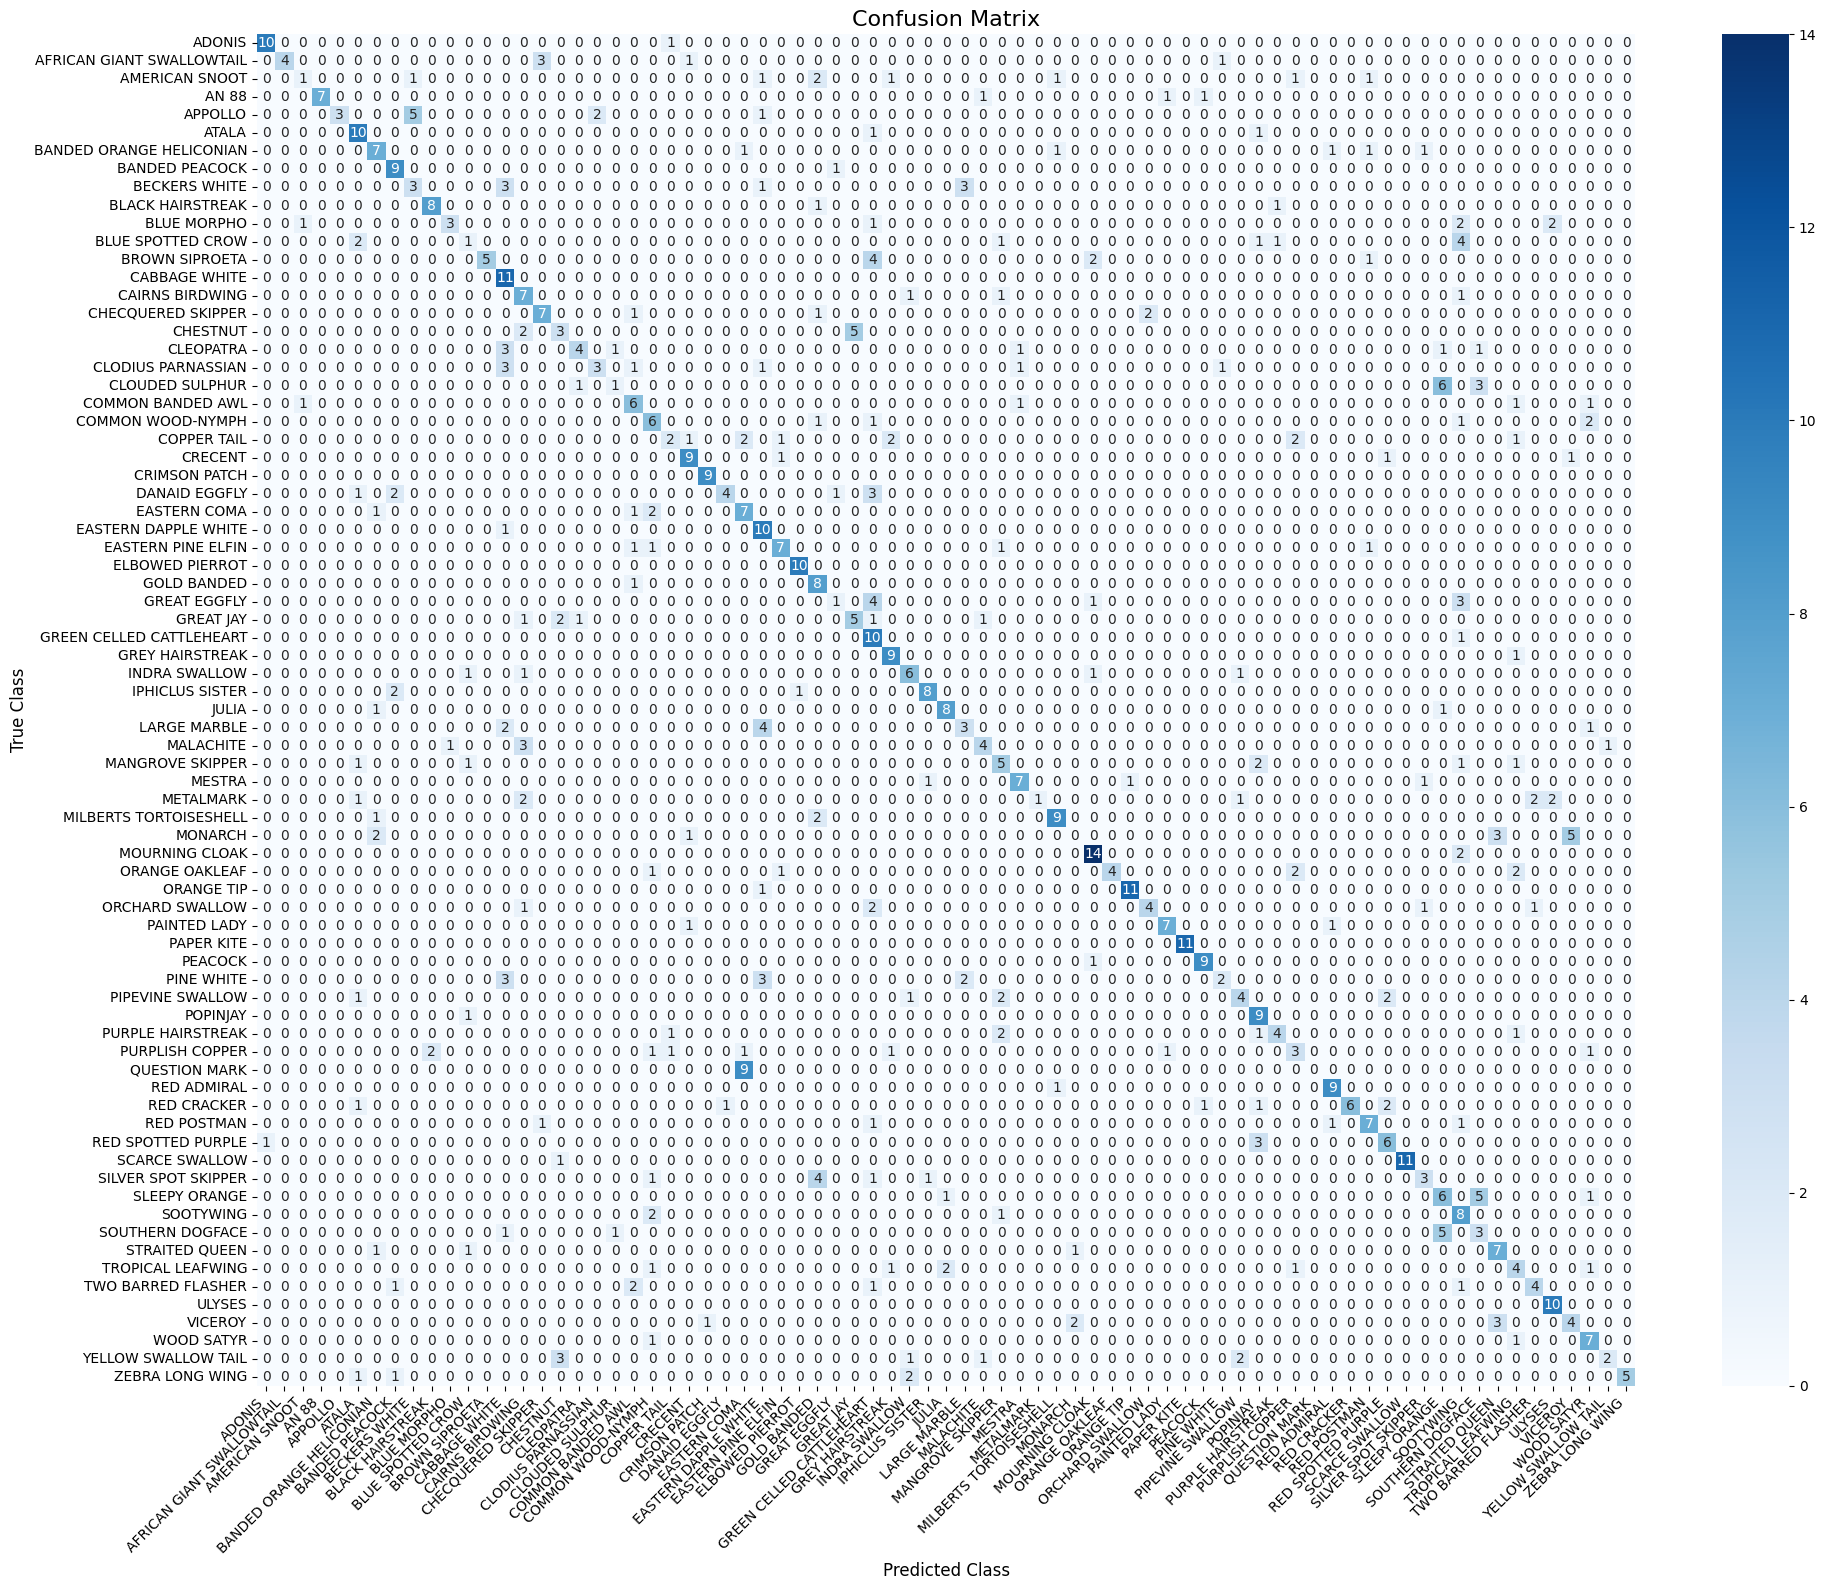

In [ ]:
print("Valutazione finale della CNN aumentata con cGAN sul Test Set...")
cgan_test_results = evaluate_on_test(
    model=cgan_augmented_model,
    test_loader=test_loader,
    device=device,
    class_names=train_dataset.classes
)

In [ ]:
generate_kaggle_submission(
    model=cgan_augmented_model,
    test_dir=test_dir,
    transform=data_transform,
    device=device,
    class_names=test_dataset.classes,
    save_name='gan_submission.csv')

Processing 1300 images for the submission...
Success! Submission saved to: /content/drive/MyDrive/AdvancedMachineLearning2/gan_submission.csv


,filename,label
0,Image_0.jpg,RED ADMIRAL
1,Image_1.jpg,BECKERS WHITE
2,Image_10.jpg,MANGROVE SKIPPER
3,Image_100.jpg,POPINJAY
4,Image_1000.jpg,GREAT JAY
...,...,...
1295,Image_995.jpg,INDRA SWALLOW
1296,Image_996.jpg,AMERICAN SNOOT
1297,Image_997.jpg,LARGE MARBLE
1298,Image_998.jpg,MONARCH


In [ ]:
from sklearn.metrics import classification_report

def get_class_f1_scores(all_labels, all_preds, class_names):

    report = classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    class_f1 = {}

    for class_name in class_names:
        class_f1[class_name] = report[class_name]['f1-score']

    return class_f1

In [ ]:
baseline_f1 = get_class_f1_scores(
    baseline_results['labels'],
    baseline_results['predictions'],
    train_dataset.classes
)

gan_f1 = get_class_f1_scores(
    cgan_test_results['labels'],
    cgan_test_results['predictions'],
    train_dataset.classes
)


print("\n===== WORST CLASSES COMPARISON =====\n")

for cls in worst_class_names:

    before = baseline_f1[cls]
    after = gan_f1[cls]

    improvement = after - before

    print(f"{cls}")
    print(f"Before GAN: {before:.3f}")
    print(f"After GAN : {after:.3f}")
    print(f"Improvement: {improvement:+.3f}")
    print("-" * 40)


===== WORST CLASSES COMPARISON =====

MESTRA
Before GAN: 0.143
After GAN : 0.700
Improvement: +0.557
----------------------------------------
SOUTHERN DOGFACE
Before GAN: 0.000
After GAN : 0.273
Improvement: +0.273
----------------------------------------
BECKERS WHITE
Before GAN: 0.000
After GAN : 0.316
Improvement: +0.316
----------------------------------------
PURPLE HAIRSTREAK
Before GAN: 0.000
After GAN : 0.533
Improvement: +0.533
----------------------------------------
PURPLISH COPPER
Before GAN: 0.000
After GAN : 0.300
Improvement: +0.300
----------------------------------------
QUESTION MARK
Before GAN: 0.000
After GAN : 0.000
Improvement: +0.000
----------------------------------------
BLUE MORPHO
Before GAN: 0.000
After GAN : 0.462
Improvement: +0.462
----------------------------------------
COPPER TAIL
Before GAN: 0.000
After GAN : 0.250
Improvement: +0.250
----------------------------------------
AFRICAN GIANT SWALLOWTAIL
Before GAN: 0.154
After GAN : 0.615
Improvement: 

## Final Comparison

                   SUMMARY OF EXPERIMENTAL RESULTS (VALIDATION SET)          
╒════════════════════════════════════╤═══════════════════════════╤══════════════════╤═════════════════════════════════════════════════╕
│ Model Configuration                │   Validation Accuracy (%) │   Macro F1-Score │ Data Strategy                                   │
╞════════════════════════════════════╪═══════════════════════════╪══════════════════╪═════════════════════════════════════════════════╡
│ Baseline CNN (Original Dataset)    │                   52.1795 │         0.482213 │ Pure Real Data (No balancing)                   │
├────────────────────────────────────┼───────────────────────────┼──────────────────┼─────────────────────────────────────────────────┤
│ Baseline CNN + Simple Augmentation │                   56.0256 │         0.523691 │ Flips + Rotations + Color Jitter (Weak Classes) │
├────────────────────────────────────┼───────────────────────────┼──────────────────┼─────────────────────

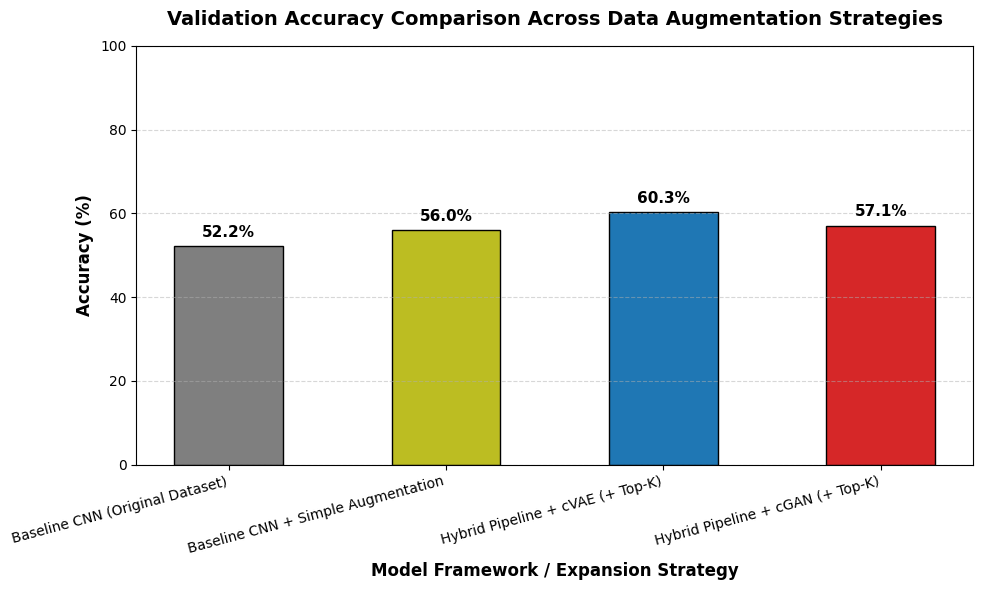

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from tabulate import tabulate

# ============================================================
# 1. DIZIONARIO DEI RISULTATI REALI OTTENUTI
# ============================================================

# save the values of accuracy and f1-scores
baseline_acc = baseline_results['accuracy'] * 100
baseline_f1_macro = baseline_results['macro_f1']

simple_aug_acc = augmented_results['accuracy'] * 100
simple_aug_f1_macro = augmented_results['macro_f1']

cvae_acc = vae_topk_results['accuracy'] * 100
cvae_f1_macro = vae_topk_results['macro_f1']

cgan_acc = cgan_test_results['accuracy'] * 100
cgan_f1_macro = cgan_test_results['macro_f1']


results_data = {
    "Model Configuration": [
        "Baseline CNN (Original Dataset)",
        "Baseline CNN + Simple Augmentation",
        "Hybrid Pipeline + cVAE (+ Top-K)",
        "Hybrid Pipeline + cGAN (+ Top-K)"
    ],
    "Validation Accuracy (%)": [baseline_acc, simple_aug_acc, cvae_acc, cgan_acc],
    "Macro F1-Score": [baseline_f1_macro, simple_aug_f1_macro, cvae_f1_macro, cgan_f1_macro],
    "Data Strategy": [
        "Pure Real Data (No balancing)",
        "Flips + Rotations + Color Jitter (Weak Classes)",
        "Real + Simple Aug. + Synthetic cGAN (Top-80)",
        "Real + Simple Aug. + Synthetic cVAE (Top-80)"
    ]
}

# Creiamo un comodo DataFrame di Pandas
df_results = pd.DataFrame(results_data)

# ============================================================
# 2. STAMPA DELLA TABELLA FORMATTATA IN CONSOLE
# ============================================================
print("="*90)
print("                   SUMMARY OF EXPERIMENTAL RESULTS (VALIDATION SET)          ")
print("="*90)
print(tabulate(df_results, headers='keys', tablefmt='fancy_grid', showindex=False))
print("="*90)

# ============================================================
# 3. GENERAZIONE DEL GRAFICO COMPARATIVO PER IL REPORT
# ============================================================
plt.figure(figsize=(10, 6))

# Scegliamo una palette di colori accademica e pulita
colors = ['#7f7f7f', '#bcbd22', '#1f77b4', '#d62728'] # Rosso evidenziato per il cVAE trionfatore

# Grafico a barre per l'Accuratezza
bars = plt.bar(
    df_results["Model Configuration"], 
    df_results["Validation Accuracy (%)"], 
    color=colors, 
    edgecolor='black', 
    width=0.5
)

# Configurazione dettagliata degli assi
plt.title("Validation Accuracy Comparison Across Data Augmentation Strategies", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Accuracy (%)", fontsize=12, fontweight='bold')
plt.xlabel("Model Framework / Expansion Strategy", fontsize=12, fontweight='bold')
plt.ylim(0, 100) # Manteniamo lo spettro totale 0-100% per rigore scientifico
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Aggiungiamo i valori numerici precisi sopra ogni barra
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2.0, 
        yval + 1.5, 
        f"{yval:.1f}%", 
        ha='center', 
        va='bottom', 
        fontsize=11, 
        fontweight='bold'
    )

# Ruotiamo i testi dell'asse X per non farli sovrapporre
plt.xticks(rotation=15, ha='right', fontsize=10)
plt.tight_layout()

# Salviamo automaticamente l'immagine sul file system di Colab in alta definizione
plt.savefig("validation_accuracy_comparison.png", dpi=300)
print("\n[INFO] Grafico 'validation_accuracy_comparison.png' salvato con successo in HD nella barra laterale!")
plt.show()